In [2]:
import numpy as np
import nibabel as nib
from nilearn import datasets
import os.path as op
import os
import pandas as pd
from brainspace.gradient import GradientMaps
from brainspace.utils.parcellation import map_to_labels
import matplotlib.pyplot as plt
import numpy as np
import pickle

from neuromaps.datasets import fetch_annotation, describe_annotations
from neuromaps import transforms
from my_utils import get_basic_mask


pixdim[1,2,3] should be non-zero; setting 0 dims to 1


In [3]:
sub_dir = '/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk/derivatives/glm_stim1.denoise'
#sub_dir = '/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-numrisk/derivatives/glm_stim.denoise.coOccCV/'

subList = sorted([f[4:6] for f in os.listdir(sub_dir) 
            if f.startswith("sub-") and len(f) == 6], key=lambda x: int(x))
subList = [s for s in subList if s != '03']

print(subList)

['01', '02', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66']


In [4]:
import os.path as op
import pandas as pd

home_dir = "/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk/derivatives/phenotype/"
percep_mem_noise = pd.read_csv(op.join(home_dir, "magjudge_bauer-3_sds_unbiased.csv"))

# Group 0: get list of subjects, format as zero-padded strings
g0_raw = percep_mem_noise.loc[percep_mem_noise['group'] == 0, 'subject'].tolist()
g0_formatted = [f"{int(s):02d}" for s in g0_raw]

# group 0 subjects
sublist_group0 = [s for s in g0_formatted if s != '03']

print(f"Group 0: {sublist_group0}")

# Group 1: same procedure
g1_raw = percep_mem_noise.loc[percep_mem_noise['group'] == 1, 'subject'].tolist()
g1_formatted = [f"{int(s):02d}" for s in g1_raw]

sublist_group1 = g1_formatted

print("Group 1:", sublist_group1)


Group 0: ['01', '05', '07', '09', '10', '12', '14', '15', '18', '19', '20', '21', '24', '28', '30', '31', '35', '36', '52', '53', '54', '55', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66']
Group 1: ['02', '04', '06', '08', '11', '13', '16', '17', '22', '23', '25', '26', '27', '29', '32', '33', '34', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '56']


In [7]:
# redo codes from above but with filtering out vertices that have beta values below -1.3 and above 1.4  (filtering out 10% of the data), again check code outliers_threshold

lower_threshold = np.load("/home/ubuntu/data/thresholds/threshold_5_perc.npy")
upper_threshold = np.load("/home/ubuntu/data/thresholds/threshold_95_perc.npy")

print(lower_threshold)
print(upper_threshold)

-1.319553256034851
1.4239275455474854


In [19]:
# filter the nans

sub_dir = '/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-numrisk/derivatives/'

stimuli = ['1', '2']
hemis = ['L', 'R']

filtered_gii = {}  # Dictionary to store filtered GIFTI files

for stim in stimuli:
    stim_dir = op.join(sub_dir, 'glm_stim.denoise.coOccCV') # f'glm_stim{stim}.denoise')
    
    for sub in subList:
        subj_dir = op.join(stim_dir, f'sub-{sub}/ses-1/func/')

        for hemi in hemis:
            filename = os.path.join(subj_dir, f'sub-{sub}_ses-1_task-magjudge_space-fsaverage5_stim-{stim}_hemi-{hemi}.func.gii')
            if not op.exists(filename):
                print(f"Missing file: {filename}")
                continue

            gii = nib.load(filename)
            n_timepoints = len(gii.darrays)  # Number of time points
            print(n_timepoints)

            # Process each time point
            for t in range(n_timepoints):
                data = gii.darrays[t].data  # Data for this time point

                # Set values below lower_threshold and above upper_threshold to NaN
                nan_mask = (data < lower_threshold) | (data > upper_threshold)
                data[nan_mask] = np.nan
                gii.darrays[t].data = data  # update the darray

            # Store in dictionary with a tuple key
            filtered_gii[(sub, stim, hemi)] = gii

# Directory to save the filtered GIFTI dictionary
save_dir = '/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-numrisk/derivatives/average_act.glm' #'/home/ubuntu/data/nan_filtered'
os.makedirs(save_dir, exist_ok=True)

# Save filtered_gii with pickle
save_path = os.path.join(save_dir, 'filtered_gii_numrisk.npy')
with open(save_path, 'wb') as f:
    pickle.dump(filtered_gii, f)

print(f"Filtered GIFTI dictionary saved to {save_path}")

216
216
216
216
216
216
216
216
216
216
216
216
216
216
216
216
216
216
216
216
216
216
216
216
216
216
216
216
216
216
216
216
216
216
216
216
216
216
216
216
216
216
216
216
216
216
216
216
216
216
216
216
216
216
Missing file: /mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-numrisk/derivatives/glm_stim.denoise.coOccCV/sub-29/ses-1/func/sub-29_ses-1_task-magjudge_space-fsaverage5_stim-1_hemi-L.func.gii
Missing file: /mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-numrisk/derivatives/glm_stim.denoise.coOccCV/sub-29/ses-1/func/sub-29_ses-1_task-magjudge_space-fsaverage5_stim-1_hemi-R.func.gii
216
216
Missing file: /mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-numrisk/derivatives/glm_stim.denoise.coOccCV/sub-31/ses-1/func/sub-31_ses-1_task-magjudge_space-fsaverage5_stim-1_hemi-L.func.gii
Missing file: /mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-numrisk/derivatives/glm_stim.denoise.coOccCV/sub-31/ses-1/func/sub-31_ses-1_task-magjudge_space-fsaverage5_stim-1_hemi-R.func.gii


In [8]:
# Compute mean over timepoints per vertex for all filtered_gii entries and save in a dictionary

mean_maps = {}  # key: (sub, stim, hemi), value: mean_per_vertex

filtered_gii = np.load('/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-numrisk/derivatives/average_act.glm/filtered_gii_numrisk.npy', allow_pickle=True)
#filtered_gii = np.load('/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk/derivatives/average_act.glm/filtered_gii.npy', allow_pickle=True)

for key, gii in filtered_gii.items():
    # Stack all timepoints into a 2D array: (n_vertices, n_timepoints)
    data_stack = np.stack([darray.data for darray in gii.darrays], axis=1)
    # Mean over timepoints (axis=0), shape: (n_vertices,)
    mean_per_vertex = np.nanmean(data_stack, axis=1)
    mean_maps[key] = mean_per_vertex

# sanity check print shape for a few entries
for key in list(mean_maps.keys())[:5]:
    print(f"{key}: {mean_maps[key].shape}")

/tmp/ipykernel_175548/2823735218.py:12: RuntimeWarning: Mean of empty slice
  mean_per_vertex = np.nanmean(data_stack, axis=1)


('01', '1', 'L'): (10242,)
('01', '1', 'R'): (10242,)
('02', '1', 'L'): (10242,)
('02', '1', 'R'): (10242,)
('03', '1', 'L'): (10242,)


In [2]:
import numpy as np

filtered_gii = np.load('/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-numrisk/derivatives/average_act.glm/filtered_gii_numrisk.npy', allow_pickle=True)


In [6]:
len(filtered_gii)/4

56.0

In [ ]:
# concatenate hemispheres and apply the mask

out_dir = "/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-numrisk/derivatives/average_act.glm/mean_maps_nan_filtered.glm/" #mean_maps_nan_filtered.glm
os.makedirs(out_dir, exist_ok=True)

mask, labeling_noParcel = get_basic_mask()  # get your mask
masked_mean_maps = {}  # key: (sub, stim), value: masked vector

subjects = sorted(set([key[0] for key in mean_maps.keys()]))
stimuli = sorted(set([key[1] for key in mean_maps.keys()]))

for sub in subjects:

    for stim in stimuli:
        hemi_data = []

        for hemi in ['L', 'R']:
            key = (sub, stim, hemi)

            if key not in mean_maps:
                print(f"Missing {key}")
                continue

            hemi_data.append(mean_maps[key])
            
        if len(hemi_data) == 2:
            combined = np.concatenate(hemi_data)
            masked = combined[mask]
            masked_mean_maps[(sub, stim)] = masked

            # save as npy file
            fname = f"sub-{sub}_stim-{stim}_masked_nan_filtered.npy"
            fpath = os.path.join(out_dir,f'stim-{stim}', f'sub-{sub}', fname)
            os.makedirs(os.path.dirname(fpath), exist_ok=True)
            np.save(fpath, masked)

            print(f"Saved {fpath} with shape {masked.shape}")
            print(f"{sub}, {stim}: masked shape {masked.shape}")

[fetch_atlas_surf_destrieux] Dataset found in /home/ubuntu/nilearn_data/destrieux_surface
Saved /mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-numrisk/derivatives/average_act.glm/mean_maps_nan_filtered.glm/stim-1/sub-01/sub-01_stim-1_masked_nan_filtered.npy with shape (18715,)
01, 1: masked shape (18715,)
Saved /mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-numrisk/derivatives/average_act.glm/mean_maps_nan_filtered.glm/stim-2/sub-01/sub-01_stim-2_masked_nan_filtered.npy with shape (18715,)
01, 2: masked shape (18715,)
Saved /mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-numrisk/derivatives/average_act.glm/mean_maps_nan_filtered.glm/stim-1/sub-02/sub-02_stim-1_masked_nan_filtered.npy with shape (18715,)
02, 1: masked shape (18715,)
Saved /mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-numrisk/derivatives/average_act.glm/mean_maps_nan_filtered.glm/stim-2/sub-02/sub-02_stim-2_masked_nan_filtered.npy with shape (18715,)
02, 2: masked shape (18715,)
Saved /mnt_AdaBD_largefiles/Da

/home/ubuntu/git/percep_mem_decision/dnumrisk_data/my_utils.py:171: UserWarning: 
The following regions are present in the atlas look-up table,
but missing from the atlas image:

 index    name
     0 Unknown

  atlas = datasets.fetch_atlas_surf_destrieux()
/home/ubuntu/git/percep_mem_decision/dnumrisk_data/my_utils.py:171: UserWarning: 
The following regions are present in the atlas look-up table,
but missing from the atlas image:

 index    name
     0 Unknown

  atlas = datasets.fetch_atlas_surf_destrieux()


Saved /mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-numrisk/derivatives/average_act.glm/mean_maps_nan_filtered.glm/stim-2/sub-11/sub-11_stim-2_masked_nan_filtered.npy with shape (18715,)
11, 2: masked shape (18715,)
Saved /mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-numrisk/derivatives/average_act.glm/mean_maps_nan_filtered.glm/stim-1/sub-12/sub-12_stim-1_masked_nan_filtered.npy with shape (18715,)
12, 1: masked shape (18715,)
Saved /mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-numrisk/derivatives/average_act.glm/mean_maps_nan_filtered.glm/stim-2/sub-12/sub-12_stim-2_masked_nan_filtered.npy with shape (18715,)
12, 2: masked shape (18715,)
Saved /mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-numrisk/derivatives/average_act.glm/mean_maps_nan_filtered.glm/stim-1/sub-13/sub-13_stim-1_masked_nan_filtered.npy with shape (18715,)
13, 1: masked shape (18715,)
Saved /mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-numrisk/derivatives/average_act.glm/mean_maps_nan_filtered.glm/s

In [17]:
# bin these values now

import pandas as pd
import os.path as op
import numpy as np
import os
from my_utils import get_basic_mask
from pathlib import Path


mask, labeling_noParcel = get_basic_mask()

# paths
#marg_dir = "/home/ubuntu/data/margulies_grad_fsav5"
#grad_dir = '/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk/derivatives/gradients.tryParams.36P' # gradients.36Pscrub3BPfilterrunFD104
#sub_dir = "/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk/derivatives/average_act.glm/mean_maps.glm"
#in_dir = '/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk/derivatives/average_act.glm/mean_maps_nan_filtered.glm' #"/home/ubuntu/data/nan_filtered/mean_maps_nan_filtered.glm/" 

grad_dir = '/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-numrisk/derivatives/gradients' # gradients.36Pscrub3BPfilterrunFD104
in_dir = '/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-numrisk/derivatives/average_act.glm/mean_maps_nan_filtered.glm' 

grad_nrs = [1, 2, 3]
spec = 'g-aligned'
kernel = 'normalized_angle'
ztransf = 'ztransf-True'

aligned = 'av.timeseries-aligned'
flipped = '' # _flipped
n_bins = 20

# bin_assignment = np.load(op.join(marg_dir, f"binned_marg_grad{grad_nr}_uneven_masked.npy"))

# dictionaries storing 1D arrays of length n_bins per subject per stimulus
df_nan = {}
vertex_bin_assignments_nan = {} 

masked_mean_maps = {}

stimuli = ['1', '2']# sorted(set([key[1] for key in masked_mean_maps.keys()]))

for grad_nr in grad_nrs:
    for stim in stimuli:
        rows_nan = []

        for sub in subList:
            try:
                # folder = Path(grad_dir) / f'sub-{sub}'
                # base = f"sub-{sub}_g-aligned-tanH_kernel-normalized_angle_ztransf-True" #f'sub-{sub}_g-aligned_space-fsaverag5_n10'

                # for suffix in ["_ccfilter", ""]:
                #     filepath = folder / f"{base}{suffix}.npy"
                #     if filepath.exists():
                #         data = np.load(filepath)
                #         print(f"Loaded: {filepath.name}")
                #         break
                # else:
                #     # show what IS there to debug
                #     folder = Path(grad_dir) / f'sub-{sub}'
                #     print(f"No file found for sub-{sub}. Files present: {list(folder.glob('*.npy'))}")
                #     continue  # skip this subject explicitly

                data = np.load(op.join(grad_dir, f'sub-{sub}', f'sub-{sub}_ses-1_task-magjudge_{ztransf}_{spec}.npy'))

                # creating bin-assignment vectors
                grad_vec_unmask = data #np.load(op.join(grad_dir, f'sub-{sub}', f"sub-{sub}_g-aligned-tanH_kernel-normalized_angle_ztransf-True_ccfilter.npy"))

                if grad_nr == 1: # grad_nr == 1 or  or grad_nr == 3
                    grad_vec =grad_vec_unmask[grad_nr-1][mask]
                else:
                    grad_vec = grad_vec_unmask[grad_nr-1][mask]

                n_vertices = len(grad_vec)
                n_bins = 20  # 5% per bin

                # defining edges
                grad_min = np.nanmin(grad_vec)
                grad_max = np.nanmax(grad_vec)
                bin_edges = np.linspace(grad_min, grad_max, n_bins + 1)

                bin_indices = np.digitize(grad_vec, bin_edges, right=True) - 1

                # Ensure all indices are within 0..n_bins-1
                bin_assignment = np.clip(bin_indices, 0, n_bins-1)

                ###############

                # load masked_mean_maps
                fname = f"sub-{sub}_stim-{stim}_masked_nan_filtered.npy"
                fpath = op.join(in_dir, f'stim-{stim}', f'sub-{sub}', fname)
                masked = np.load(fpath)
                masked_mean_maps[(sub, stim)] = masked

                subj_vec = (masked_mean_maps[(sub, stim)])

                # assign bin number to vertices
                vertex_bin_assignment_nan = np.column_stack((subj_vec, bin_assignment))
                
                # compute mean per bin
                bin_means_nan = [np.nanmean(subj_vec[bin_assignment == b]) for b in range(n_bins)]
                row_nan = {'subject': f"sub-{sub}"}
                for b in range(n_bins):
                    row_nan[f'bin_{b}'] = bin_means_nan[b]
                rows_nan.append(row_nan)

            except Exception as e:
                print(f"Error for sub-{sub} stim-{stim}: {e}")
                continue
            
        # Create DataFrames per stimulus
        df_nan[stim] = pd.DataFrame(rows_nan)


    df_stim1_nan = df_nan["1"]
    df_stim2_nan = df_nan["2"]


    out_dir =  '/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-numrisk/derivatives/activation_maps_bins.glmav' # '/home/ubuntu/data/activation_maps_bins.glmav/'
    df_stim1_nan.to_csv(op.join(out_dir, f"df_stim1_grad{grad_nr}_nan_uneven_new_{aligned}{flipped}.csv"), index=False) # df_stim1_nan
    df_stim2_nan.to_csv(op.join(out_dir, f"df_stim2_grad{grad_nr}_nan_uneven_new_{aligned}{flipped}.csv"), index=False) # df_stim2_nan

[fetch_atlas_surf_destrieux] Dataset found in /home/ubuntu/nilearn_data/destrieux_surface


/home/ubuntu/git/percep_mem_decision/dnumrisk_data/my_utils.py:171: UserWarning: 
The following regions are present in the atlas look-up table,
but missing from the atlas image:

 index    name
     0 Unknown

  atlas = datasets.fetch_atlas_surf_destrieux()
/home/ubuntu/git/percep_mem_decision/dnumrisk_data/my_utils.py:171: UserWarning: 
The following regions are present in the atlas look-up table,
but missing from the atlas image:

 index    name
     0 Unknown

  atlas = datasets.fetch_atlas_surf_destrieux()


Error for sub-29 stim-1: [Errno 2] No such file or directory: '/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-numrisk/derivatives/average_act.glm/mean_maps_nan_filtered.glm/stim-1/sub-29/sub-29_stim-1_masked_nan_filtered.npy'
Error for sub-31 stim-1: [Errno 2] No such file or directory: '/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-numrisk/derivatives/average_act.glm/mean_maps_nan_filtered.glm/stim-1/sub-31/sub-31_stim-1_masked_nan_filtered.npy'
Error for sub-35 stim-1: [Errno 2] No such file or directory: '/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-numrisk/derivatives/average_act.glm/mean_maps_nan_filtered.glm/stim-1/sub-35/sub-35_stim-1_masked_nan_filtered.npy'
Error for sub-36 stim-1: [Errno 2] No such file or directory: '/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-numrisk/derivatives/average_act.glm/mean_maps_nan_filtered.glm/stim-1/sub-36/sub-36_stim-1_masked_nan_filtered.npy'
Error for sub-40 stim-1: [Errno 2] No such file or directory: '/mnt_AdaBD_largefiles

In [19]:
len(df_stim1_nan)

56

[fetch_atlas_surf_destrieux] Dataset found in /home/ubuntu/nilearn_data/destrieux_surface


/home/ubuntu/git/percep_mem_decision/dnumrisk_data/my_utils.py:171: UserWarning: 
The following regions are present in the atlas look-up table,
but missing from the atlas image:

 index    name
     0 Unknown

  atlas = datasets.fetch_atlas_surf_destrieux()
/home/ubuntu/git/percep_mem_decision/dnumrisk_data/my_utils.py:171: UserWarning: 
The following regions are present in the atlas look-up table,
but missing from the atlas image:

 index    name
     0 Unknown

  atlas = datasets.fetch_atlas_surf_destrieux()
/tmp/ipykernel_240334/2840878211.py:52: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  nplt.plot_surf(surf_mesh= fsaverage.infl_right, surf_map= gm_r, # infl_right # pial_right


Text(0.5, 0.98, 'g-aligned kernel normalized_angle')

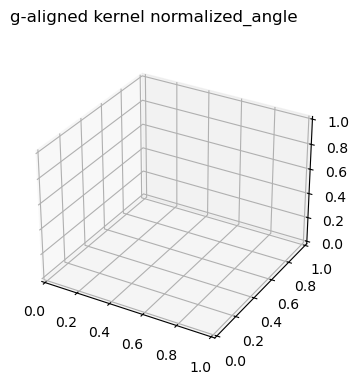

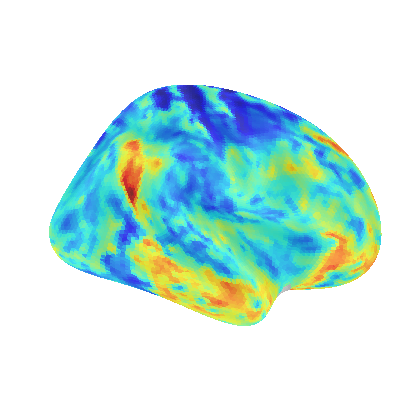

In [24]:
# plot sub gradients to check????
# bin these values now

import pandas as pd
import os.path as op
import numpy as np
import os
from my_utils import get_basic_mask
import nilearn.plotting as nplt
import matplotlib.pyplot as plt
from  nilearn.datasets import fetch_surf_fsaverage
fsaverage = fetch_surf_fsaverage() # default 5

mask, labeling_noParcel = get_basic_mask()

# paths
#marg_dir = "/home/ubuntu/data/margulies_grad_fsav5"
#grad_dir = '/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk/derivatives/gradients.36Pscrub3BPfilterrunFD104'
grad_dir = '/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-numrisk/derivatives/gradients' # gradients.36Pscrub3BPfilterrunFD104
sub_dir = "/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-numrisk/derivatives/average_act.glm/mean_maps.glm"
in_dir = "/home/ubuntu/data/nan_filtered/mean_maps_nan_filtered.glm/"

grad_nr = 1
spec = 'g-aligned'
kernel = 'normalized_angle'
ztransf = 'ztransf-True'

aligned = 'av.timeseries-aligned'
n_bins = 20

# bin_assignment = np.load(op.join(marg_dir, f"binned_marg_grad{grad_nr}_uneven_masked.npy"))

subList = ['10']

for sub in subList:
    # creating bin-assignment vectors
    grad_vec_unmask = np.load(op.join(grad_dir, f'sub-{sub}', f'sub-{sub}_ses-1_task-magjudge_{ztransf}_{spec}.npy'))
    grad_vec = grad_vec_unmask[grad_nr-1]#[mask]

    # plotting gradients
    side_view = 'medial'
    cmap = 'jet'
    n_comp = 5

    figure, axes = plt.subplots(1, 1,figsize = (15,4), subplot_kw=dict(projection='3d'))


    gm = np.split(grad_vec,2) # for i, hemi in enumerate([‘L’, ‘R’]): --> left first

    gm_r = gm[1]
    
    nplt.plot_surf(surf_mesh= fsaverage.infl_right, surf_map= gm_r, # infl_right # pial_right
                view= side_view,cmap=cmap, colorbar=False,  # sub-{sub}, title=f’grad {i+1}‘,
                bg_map=fsaverage.sulc_right, bg_on_data=True,darkness=0.7) #
    #axes[j, i].set(title=f'grad {i+1} stim {stim}')
figure.suptitle(f'{spec} kernel {kernel}')

In [7]:
# load the data

grad_nr = 1
aligned = 'av.timeseries-aligned' # sub-aligned
flipped = '_flipped' #

out_dir = '/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk/derivatives/activation_maps_bins.glmav' # '/home/ubuntu/data/activation_maps_bins.glmav'

df_stim1_nan = pd.read_csv(op.join(out_dir, f"df_stim1_grad{grad_nr}_nan_uneven_new_{aligned}{flipped}.csv"))
df_stim2_nan = pd.read_csv(op.join(out_dir, f"df_stim2_grad{grad_nr}_nan_uneven_new_{aligned}{flipped}.csv"))


Gradient 1:
 Bin        t      p_raw      p_fdr
   0   -5.628     0.0000     0.0000
df: 64
   1   -7.120     0.0000     0.0000
df: 64
   2   -4.385     0.0000     0.0001
df: 64
   3   -0.719     0.4748     0.4998
df: 64
   4    0.810     0.4211     0.4679
df: 64
   5   -0.982     0.3296     0.3878
df: 64
   6   -4.047     0.0001     0.0002
df: 64
   7   -5.626     0.0000     0.0000
df: 64
   8   -6.341     0.0000     0.0000
df: 64
   9   -5.297     0.0000     0.0000
df: 64
  10   -4.864     0.0000     0.0000
df: 64
  11   -2.696     0.0089     0.0119
df: 64
  12   -0.175     0.8618     0.8618
df: 64
  13    2.345     0.0222     0.0277
df: 64
  14    4.609     0.0000     0.0000
df: 64
  15    6.105     0.0000     0.0000
df: 64
  16    6.928     0.0000     0.0000
df: 64
  17    7.822     0.0000     0.0000
df: 64
  18    9.143     0.0000     0.0000
df: 64
  19    8.519     0.0000     0.0000
df: 64

Gradient 2:
 Bin        t      p_raw      p_fdr
   0   -6.818     0.0000     0.0000
df: 64

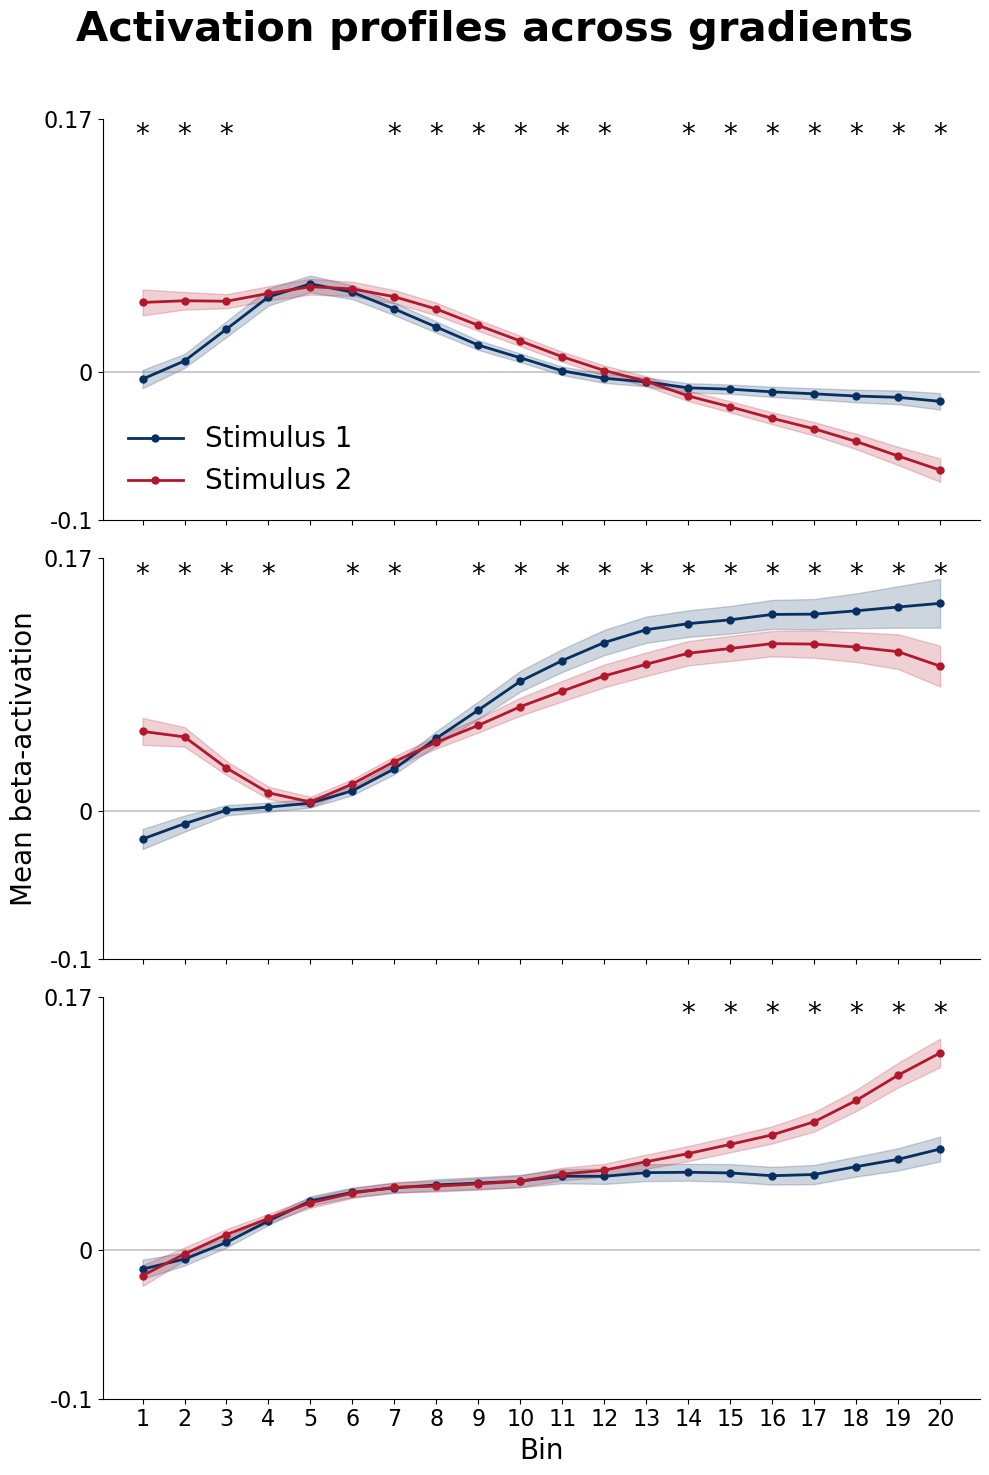

In [9]:
import seaborn as sns
from scipy.stats import ttest_rel
from statsmodels.stats.multitest import multipletests

out_dir = '/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk/derivatives/activation_maps_bins.glmav' # '/home/ubuntu/data/activation_maps_bins.glmav'
grad_nrs = [1, 2, 3]

size_title = 30
size_other = 20
size_axis = 16

color_stim1 = '#053061'
color_stim2 = '#b2182b'
ymin = -0.1
ymax = 0.17
bins = 20

fig, axes = plt.subplots(len(grad_nrs), 1, figsize=(10, 15), sharex=True)

for idx, grad_nr in enumerate(grad_nrs):

    ax = axes[idx]

    df_stim1_nan = pd.read_csv(op.join(out_dir, f"df_stim1_grad{grad_nr}_nan_uneven_new_{aligned}{flipped}.csv"))
    df_stim2_nan = pd.read_csv(op.join(out_dir, f"df_stim2_grad{grad_nr}_nan_uneven_new_{aligned}{flipped}.csv"))

    def prepare_long_format(df, stim_label):
        long_df = df.melt(id_vars=["subject"], var_name="bin", value_name="mean_activation")
        long_df["stimulus"] = stim_label
        long_df["bin"] = long_df["bin"].str.replace("bin_", "").astype(int)
        return long_df

    stim1_nan_long = prepare_long_format(df_stim1_nan, "stim-1")
    stim2_nan_long = prepare_long_format(df_stim2_nan, "stim-2")

    nan_long = pd.concat([stim1_nan_long, stim2_nan_long])
    nan_long_clean = nan_long.dropna(subset=["mean_activation"])
    nan_long_clean["stimulus"] = nan_long_clean["stimulus"].map({
        "stim-1": "Stimulus 1",
        "stim-2": "Stimulus 2"
    })

    # ---- paired t-test per bin + FDR ----
    bin_list = sorted(nan_long_clean['bin'].unique())
    pvals = []

    for b in bin_list:
        s1 = nan_long_clean[(nan_long_clean['bin'] == b) & (nan_long_clean['stimulus'] == 'Stimulus 1')]\
            .set_index('subject')['mean_activation']
        s2 = nan_long_clean[(nan_long_clean['bin'] == b) & (nan_long_clean['stimulus'] == 'Stimulus 2')]\
            .set_index('subject')['mean_activation']
        # align subjects
        common = s1.index.intersection(s2.index)
        _, p = ttest_rel(s1.loc[common], s2.loc[common])
        pvals.append(p)

    _, pvals_corrected, _, _ = multipletests(pvals, method='fdr_bh')

    # ---- print t, p_raw, p_fdr per bin ----
    print(f"\nGradient {grad_nr}:")
    print(f"{'Bin':>4} {'t':>8} {'p_raw':>10} {'p_fdr':>10}")
    for b, p_raw, p_fdr in zip(bin_list, pvals, pvals_corrected):
        s1 = nan_long_clean[(nan_long_clean['bin'] == b) & (nan_long_clean['stimulus'] == 'Stimulus 1')]\
            .set_index('subject')['mean_activation']
        s2 = nan_long_clean[(nan_long_clean['bin'] == b) & (nan_long_clean['stimulus'] == 'Stimulus 2')]\
            .set_index('subject')['mean_activation']
        common = s1.index.intersection(s2.index)
        t, _ = ttest_rel(s1.loc[common], s2.loc[common])
        print(f"{b:>4} {t:>8.3f} {p_raw:>10.4f} {p_fdr:>10.4f}")
        print(f'df: {len(df_stim1_nan) - 1}')


    # ---- plot ----
    ax.grid(False)
    ax.axhline(0, color='gray', linestyle='-', linewidth=1.5, alpha=0.4)

    sns.lineplot(
        data=nan_long_clean,
        x="bin",
        y="mean_activation",
        hue="stimulus",
        palette=[color_stim1, color_stim2],
        errorbar='se',
        marker="o",
        linewidth=2,
        markeredgewidth=0,
        ax=ax
    )

    # ---- mark significant bins ----
    y_annot = ymax * 0.88
    for b, p_corr in zip(bin_list, pvals_corrected):
        if p_corr < 0.05:
            ax.text(b, y_annot, '*', ha='center', va='bottom', fontsize=size_other, color='black')

    # ---- axes ----
    ax.set_xticks(range(bins))
    ax.set_xticklabels(range(1, bins + 1), fontsize=size_axis)
    ax.set_ylim(ymin, ymax)
    ax.set_yticks([ymin, 0, ymax])
    ax.set_yticklabels([ymin, 0, ymax], fontsize=size_axis)
    ax.set_xlabel('')

    if idx == len(grad_nrs) // 2:
        ax.set_ylabel("Mean beta-activation", fontsize=size_other)
    else:
        ax.set_ylabel("")

    sns.despine(ax=ax)

    if idx == 0:
        ax.legend(title="", frameon=False, fontsize=size_other)
    else:
        ax.get_legend().remove()

axes[-1].set_xlabel("Bin", fontsize=size_other)

fig.suptitle(
    "Activation profiles across gradients",
    fontsize=size_title, weight='bold',
    y=0.98
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [5]:
# calculating similarity of beta-activation of stim 1/2 with grad per sub and then correlating that to behavior

import pandas as pd
import os.path as op
import numpy as np
import os
from my_utils import get_basic_mask
from pathlib import Path
from scipy.stats import pearsonr


mask, labeling_noParcel = get_basic_mask()

# paths
#marg_dir = "/home/ubuntu/data/margulies_grad_fsav5"
grad_dir = '/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk/derivatives/gradients.tryParams.36P'
sub_dir = "/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk/derivatives/average_act.glm/mean_maps.glm"
in_dir = "/home/ubuntu/data/nan_filtered/mean_maps_nan_filtered.glm/"

grad_nr = 3
spec = 'g-aligned'
kernel = 'normalized_angle'

aligned = 'av.timeseries-aligned'
flipped = '_flipped' 
#n_bins = 20

stimuli = ['1', '2']

corrs = {'sub': [],
         'corr_1': [], 'pval_1': [],
         'corr_2': [], 'pval_2': []}


for sub in subList:
    
    folder = Path(grad_dir) / f'sub-{sub}'
    base = f"sub-{sub}_g-aligned-tanH_kernel-normalized_angle_ztransf-True"

    for suffix in ["_ccfilter", ""]:
        filepath = folder / f"{base}{suffix}.npy"
        if filepath.exists():
            data = np.load(filepath)
            #print(f"Loaded: {filepath.name}")
            break
    else:
        # show what IS there to debug
        folder = Path(grad_dir) / f'sub-{sub}'
        print(f"No file found for sub-{sub}. Files present: {list(folder.glob('*.npy'))}")
        continue  # skip this subject explicitly

    # lading grads
    grad_vec_unmask = data
    grad_vec = grad_vec_unmask[grad_nr-1][mask]

    corrs['sub'].append(sub)

    for stim in stimuli:

        # load masked_mean_maps
        fname = f"sub-{sub}_stim-{stim}_masked_nan_filtered.npy"
        fpath = op.join(in_dir,f'stim-{stim}', f'sub-{sub}', fname)
        masked = np.load(fpath)
        masked_mean_maps = masked

        valid = ~np.isnan(grad_vec) & ~np.isnan(masked_mean_maps)

        # correlate grad and beta map
        stat, pval = pearsonr(masked_mean_maps[valid], grad_vec[valid])

        corrs[f'corr_{stim}'].append(stat)
        corrs[f'pval_{stim}'].append(pval)
    
            
df_corrs = pd.DataFrame(corrs)

[fetch_atlas_surf_destrieux] Dataset found in /home/ubuntu/nilearn_data/destrieux_surface


/home/ubuntu/git/percep_mem_decision/dnumrisk_data/my_utils.py:171: UserWarning: 
The following regions are present in the atlas look-up table,
but missing from the atlas image:

 index    name
     0 Unknown

  atlas = datasets.fetch_atlas_surf_destrieux()
/home/ubuntu/git/percep_mem_decision/dnumrisk_data/my_utils.py:171: UserWarning: 
The following regions are present in the atlas look-up table,
but missing from the atlas image:

 index    name
     0 Unknown

  atlas = datasets.fetch_atlas_surf_destrieux()


Shapiro-Wilk on difference: p=0.259
Using: t-test_paired
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Stimulus 1 vs. Stimulus 2: t-test paired samples, P_val:7.512e-05 t=-4.247e+00


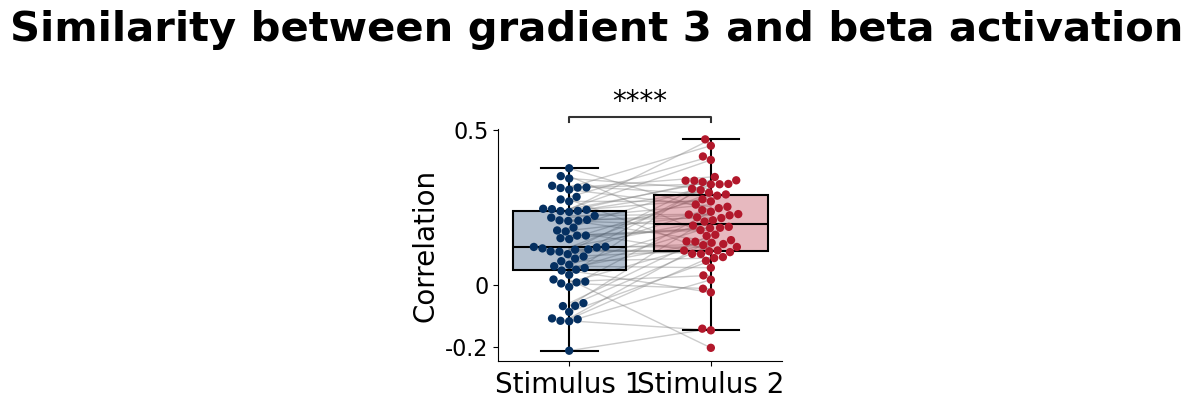

In [36]:
from scipy.stats import ttest_rel, shapiro, wilcoxon
import matplotlib.colors as mcolors
from statannotations.Annotator import Annotator
import seaborn as sns

size_title = 30
size_other = 20
size_axis  = 16

color_stim1 = '#053061'
color_stim2 = '#b2182b'
colors      = [color_stim1, color_stim2]
stim_order  = ['Stimulus 1', 'Stimulus 2']

# ── check normality ───────────────────────────────────────────────────────────
diff = df_corrs['corr_1'] - df_corrs['corr_2']
_, p_sw = shapiro(diff.dropna())
print(f"Shapiro-Wilk on difference: p={p_sw:.3f}")
stat_test = 't-test_paired' if p_sw > 0.05 else 'Wilcoxon'
print(f"Using: {stat_test}")

# ── reshape to long format for plotting ───────────────────────────────────────
valid = df_corrs['corr_1'].notna() & df_corrs['corr_2'].notna()
df_plot = pd.melt(
    df_corrs[valid].reset_index(drop=True),
    id_vars='sub',
    value_vars=['corr_1', 'corr_2'],
    var_name='stimulus',
    value_name='correlation'
)
df_plot['stimulus'] = df_plot['stimulus'].map({'corr_1': 'Stimulus 1', 'corr_2': 'Stimulus 2'})

# ── plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(4, 4))

# ---- boxplot ----
sns.boxplot(
    data=df_plot, x='stimulus', y='correlation',
    order=stim_order,
    hue='stimulus', hue_order=stim_order, legend=False,
    palette=colors,
    showfliers=False,
    linecolor='black',
    linewidth=1.5,
    ax=ax,
)

# ---- box fill alpha ----
for i, patch in enumerate(ax.patches):
    r, g, b, _ = mcolors.to_rgba(colors[i])
    patch.set_facecolor((r, g, b, 0.3))
    patch.set_edgecolor('black')

# ---- connecting lines ----
for sub in df_plot['sub'].unique():
    subj_data = df_plot[df_plot['sub'] == sub].set_index('stimulus').reindex(stim_order)
    ax.plot(
        [0, 1],
        subj_data['correlation'].values,
        color='grey', alpha=0.4, linewidth=1, zorder=0
    )

# ---- swarmplot ----
sns.swarmplot(
    data=df_plot, x='stimulus', y='correlation',
    order=stim_order,
    hue='stimulus', hue_order=stim_order, legend=False,
    palette=colors,
    alpha=1, size=6,
    ax=ax,
)

# ---- axes ----
ax.set_xlabel('', fontsize=size_other)
ax.set_yticks([-0.2, 0, 0.5])
ax.set_yticklabels([-0.2, 0, 0.5], fontsize=size_axis)
ax.set_ylabel(f'Correlation', fontsize=size_other)
ax.tick_params(axis='x', labelsize=size_other)
ax.tick_params(axis='y', labelsize=size_axis)

# ---- styling ----
ax.grid(False)
sns.despine(ax=ax)

# ---- title ----
fig.suptitle(
    f'Similarity between gradient {grad_nr} and beta activation',
    fontsize=size_title, weight='bold', y=1.01
)

# ---- stats annotation ----
pairs = [('Stimulus 1', 'Stimulus 2')]
annotator = Annotator(ax, pairs, data=df_plot, x='stimulus', y='correlation', order=stim_order)
annotator.configure(test=stat_test, text_format='star', loc='outside', fontsize=size_other)
annotator.apply_test()
annotator.annotate()

plt.tight_layout()
plt.show()

In [37]:
params_folder = '/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk/derivatives/phenotype'
bids_folder = '/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk'
plot_folder = '/Users/mrenke/data/ds-dnumrisk/plots_and_ims/phenotype'
behav_dir = '/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk/derivatives/behavioral_files'

# perceptual noise parameters
percep_mem_noise = pd.read_csv(op.join(params_folder, "magjudge_bauer-3_sds_unbiased.csv"))
filtered_percep_mem_noise = percep_mem_noise[percep_mem_noise["subject"] != 3].reset_index(drop=True) # first filtering out sub-03
filtered_percep_mem_noise.drop(columns =['perceptual_noise_sd'], inplace=True)
filtered_percep_mem_noise.set_index('subject', inplace=True)

# magjudge task performance
magjudge_perf = pd.read_csv(op.join(behav_dir, f"sub-All_ses-1_magjudge-behav.csv"))
magjudge_perf.rename(columns={'sub': 'subject'}, inplace=True)
magjudge_perf = magjudge_perf.set_index('subject') # already without sub-03

# math skill info
math_stuff = pd.read_csv(op.join(params_folder, 'math_skill-confidence-anxiety-means.csv')) #.set_index('subject')
filtered_math_stuff = math_stuff[math_stuff["subject"] != 3].reset_index(drop=True).set_index('subject')

vs_wm = pd.read_csv(op.join(params_folder, 'visio-spatial-WM_CBTtask-params.csv'))
filtered_vs_wm = vs_wm[vs_wm["subject"] != 3].reset_index(drop=True).set_index('subject')
#vs_wm.set_index('subject', inplace=True)

iq_scores = pd.read_csv(op.join(params_folder, 'iq-scores_ids2.csv')) #.set_index('subject')
filtered_iq_scores = iq_scores[iq_scores["subject"] != 3].reset_index(drop=True).set_index('subject')

df_comb = filtered_percep_mem_noise.join(magjudge_perf).join(filtered_iq_scores).join(filtered_vs_wm).join(filtered_math_stuff)
df_comb.drop(columns =['kn'], inplace=True)
df_comb.drop(columns =['basisscore'], inplace=True)
df_comb.drop(columns =['mean_iq'], inplace=True)
df_comb.drop(columns =['overall_score'], inplace=True)

print(df_comb.columns)
var_list = ['me', 'erfassungsspanne','skill_score','anx_mean', 'conf_mean']
name_list = ['Visuospatial reasoning', 'Visuospatial working memory', 'Math skills', 'Math anxiety', 'Math confidence']
#rename_dict = dict(zip(var_list, name_list))
#df_comb.rename(columns=rename_dict, inplace=True)

Index(['group', 'memory_noise_sd', 'reaction_time', 'accuracy', 'me',
       'erfassungsspanne', 'skill_score', 'anx_mean', 'conf_mean'],
      dtype='object')


[Stimulus 1] memory_noise_sd: r=-0.157, p_raw=0.2112, p_FDR=0.7753  n.s.
[Stimulus 1] reaction_time: r=0.051, p_raw=0.6850, p_FDR=0.9754  n.s.
[Stimulus 1] accuracy: r=0.010, p_raw=0.9364, p_FDR=0.9771  n.s.
[Stimulus 1] me: r=-0.101, p_raw=0.4212, p_FDR=0.9754  n.s.
[Stimulus 1] erfassungsspanne: r=-0.180, p_raw=0.1512, p_FDR=0.7753  n.s.
[Stimulus 1] skill_score: r=-0.050, p_raw=0.6909, p_FDR=0.9754  n.s.
[Stimulus 1] anx_mean: r=0.074, p_raw=0.5587, p_FDR=0.9754  n.s.
[Stimulus 1] conf_mean: r=-0.001, p_raw=0.9922, p_FDR=0.9922  n.s.
[Stimulus 2] memory_noise_sd: r=-0.156, p_raw=0.2140, p_FDR=0.7753  n.s.
[Stimulus 2] reaction_time: r=-0.015, p_raw=0.9045, p_FDR=0.9771  n.s.
[Stimulus 2] accuracy: r=0.066, p_raw=0.6017, p_FDR=0.9754  n.s.
[Stimulus 2] me: r=0.091, p_raw=0.4706, p_FDR=0.9754  n.s.
[Stimulus 2] erfassungsspanne: r=-0.014, p_raw=0.9132, p_FDR=0.9771  n.s.
[Stimulus 2] skill_score: r=0.016, p_raw=0.8976, p_FDR=0.9771  n.s.
[Stimulus 2] anx_mean: r=-0.029, p_raw=0.8187, 

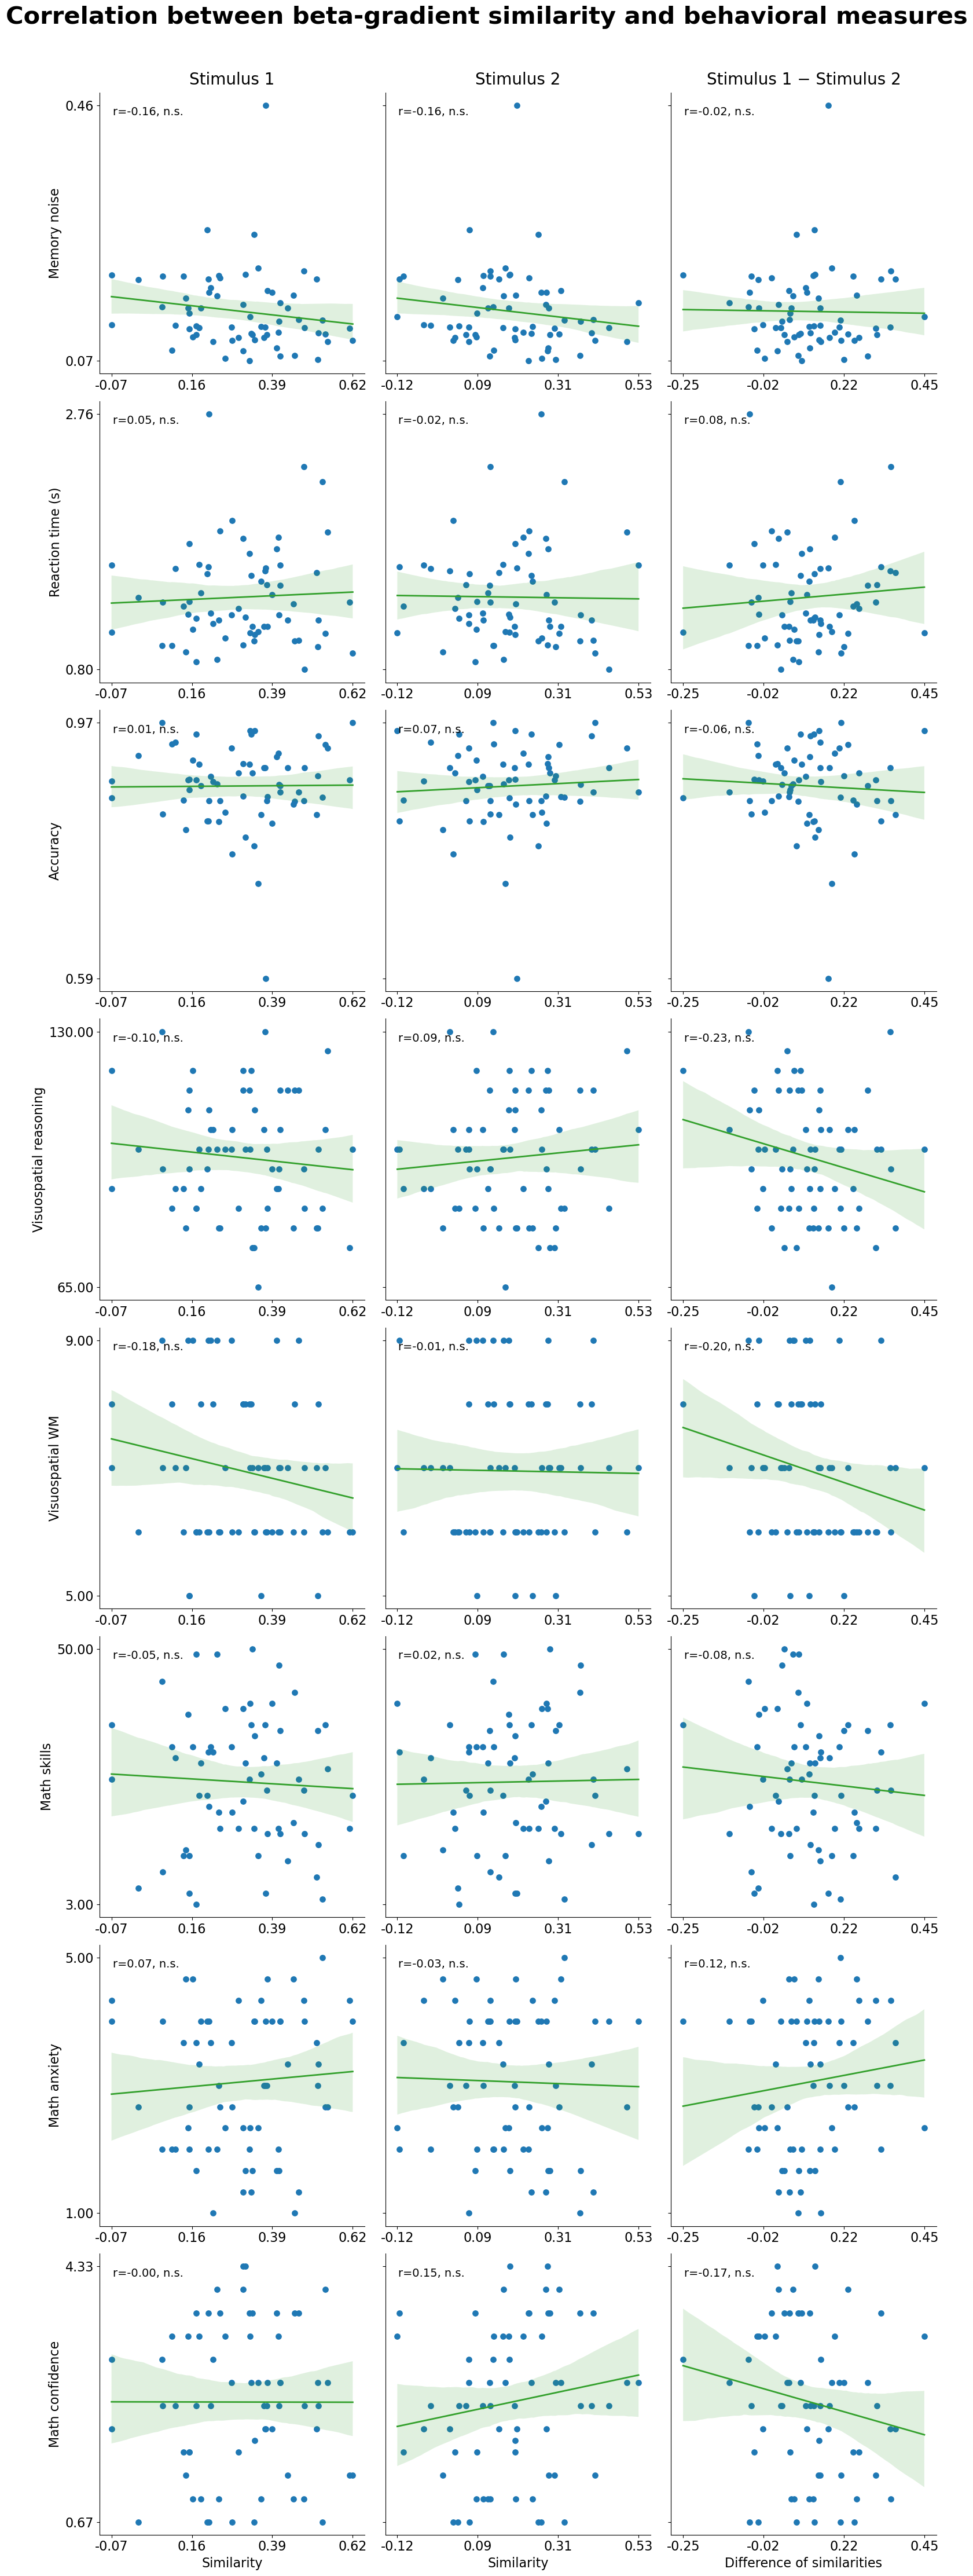

In [15]:
from scipy.stats import pearsonr, linregress
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import os.path as op

# ── style ─────────────────────────────────────────────────────────────────────
size_title = 30
size_other = 20
size_axis  = 16
colors     = ['#1f78b4', '#33a02c']

# ── x-vectors: grad-beta correlation per subject ──────────────────────────────
grad_conditions = {
    'Stimulus 1':              df_corrs['corr_1'],
    'Stimulus 2':              df_corrs['corr_2'],
    'Stimulus 1 − Stimulus 2': df_corrs['corr_1'] - df_corrs['corr_2'],
}

xlabel_map = {
    'Stimulus 1':              'Similarity',
    'Stimulus 2':              'Similarity',
    'Stimulus 1 − Stimulus 2': 'Difference of similarities',
}

behav_rows = [
    ('memory_noise_sd',  'Memory noise',      'Memory noise'),
    ('reaction_time',    'Reaction time (s)', 'Reaction time (s)'),
    ('accuracy',         'Accuracy',          'Accuracy'),
    ('me',               'Visuospatial reasoning',  'Visuospatial reasoning'),
    ('erfassungsspanne', 'Visuospatial WM',   'Visuospatial WM'),
    ('skill_score',      'Math skills',       'Math skills'),
    ('anx_mean',         'Math anxiety',      'Math anxiety'),
    ('conf_mean',        'Math confidence',   'Math confidence'),
]

# ── collect all tests ─────────────────────────────────────────────────────────
records = []
for col_idx, (grad_label, x_vec) in enumerate(grad_conditions.items()):
    for row_idx, (bvar, ylabel, ylabel_left) in enumerate(behav_rows):
        y_vec = df_comb[bvar].values
        n     = min(len(x_vec), len(y_vec))
        x_arr = x_vec.values[:n]
        y_arr = y_vec[:n]
        mask  = np.isfinite(x_arr) & np.isfinite(y_arr)
        r, p  = pearsonr(x_arr[mask], y_arr[mask])
        slope, intercept, *_ = linregress(x_arr[mask], y_arr[mask])
        records.append({
            'row':        row_idx,
            'col':        col_idx,
            'grad_label': grad_label,
            'bvar':       bvar,
            'ylabel':     ylabel_left,
            'x':          x_arr,
            'y':          y_arr,
            'mask':       mask,
            'r':          r,
            'p':          p,
            'slope':      slope,
            'intercept':  intercept,
        })

# ── FDR-BH ───────────────────────────────────────────────────────────────────
_, p_fdr, _, _ = multipletests([rec['p'] for rec in records], method='fdr_bh')
for rec, p_adj in zip(records, p_fdr):
    rec['p_fdr'] = p_adj

# ── plot ──────────────────────────────────────────────────────────────────────
n_rows, n_cols = len(behav_rows), len(grad_conditions)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 44), sharex=False, sharey=False)

for rec in records:
    ax    = axes[rec['row'], rec['col']]
    x     = rec['x'];     y     = rec['y'];     mask  = rec['mask']
    slope = rec['slope']; inter = rec['intercept']
    r     = rec['r'];     p_raw = rec['p'];     p_adj = rec['p_fdr']
    col   = rec['col'];   row   = rec['row']

    sig_str = '**' if p_adj < 0.01 else ('*' if p_adj < 0.05 else ('†' if p_adj < 0.1 else 'n.s.'))

    df_plot = pd.DataFrame({'x': x[mask], 'y': y[mask]})
    sns.regplot(data=df_plot, x='x', y='y', ax=ax,
                color=colors[0],
                scatter_kws=dict(s=60, alpha=1, linewidths=0),
                line_kws=dict(linewidth=2, color=colors[1]),
                ci=95)

    ax.text(0.05, 0.95, f'r={r:.2f}, {sig_str}', transform=ax.transAxes,
            fontsize=size_axis - 2, va='top', color='black')

    if row == 0:
        ax.set_title(rec['grad_label'], fontsize=size_other, pad=10)

    ax.set_xlabel(xlabel_map[rec['grad_label']] if row == n_rows - 1 else '', fontsize=size_axis)

    x_clean = x[mask]
    xt = np.linspace(x_clean.min(), x_clean.max(), 4)
    ax.set_xticks(xt)
    ax.set_xticklabels([f'{v:.2f}' for v in xt], fontsize=size_axis)

    y_clean = y[mask]
    ymin, ymax = y_clean.min(), y_clean.max()
    ax.set_yticks([ymin, ymax])
    if col == 0:
        ax.set_yticklabels([f'{ymin:.2f}', f'{ymax:.2f}'], fontsize=size_axis)
        ax.set_ylabel(rec['ylabel'], fontsize=size_axis)
    else:
        ax.set_yticklabels([])
        ax.set_ylabel('')

    ax.grid(False)
    sns.despine(ax=ax)

    legend = ax.get_legend()
    if legend:
        legend.remove()

    print(f'[{rec["grad_label"]}] {rec["bvar"]}: r={r:.3f}, p_raw={p_raw:.4f}, p_FDR={p_adj:.4f}  {sig_str}')

fig.suptitle('Correlation between beta-gradient similarity and behavioral measures',
             fontsize=size_title, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

[Stimulus 1] memory_noise_sd: r=-0.005, p_raw=0.9668, p_FDR=0.9954  n.s.
[Stimulus 1] reaction_time: r=-0.096, p_raw=0.4452, p_FDR=0.9954  n.s.
[Stimulus 1] accuracy: r=-0.073, p_raw=0.5612, p_FDR=0.9954  n.s.
[Stimulus 1] me: r=0.011, p_raw=0.9296, p_FDR=0.9954  n.s.
[Stimulus 1] erfassungsspanne: r=0.031, p_raw=0.8062, p_FDR=0.9954  n.s.
[Stimulus 1] skill_score: r=0.011, p_raw=0.9308, p_FDR=0.9954  n.s.
[Stimulus 1] anx_mean: r=-0.011, p_raw=0.9328, p_FDR=0.9954  n.s.
[Stimulus 1] conf_mean: r=0.054, p_raw=0.6687, p_FDR=0.9954  n.s.
[Stimulus 2] memory_noise_sd: r=-0.001, p_raw=0.9954, p_FDR=0.9954  n.s.
[Stimulus 2] reaction_time: r=0.032, p_raw=0.8023, p_FDR=0.9954  n.s.
[Stimulus 2] accuracy: r=-0.129, p_raw=0.3051, p_FDR=0.9954  n.s.
[Stimulus 2] me: r=-0.006, p_raw=0.9623, p_FDR=0.9954  n.s.
[Stimulus 2] erfassungsspanne: r=-0.086, p_raw=0.4976, p_FDR=0.9954  n.s.
[Stimulus 2] skill_score: r=-0.112, p_raw=0.3753, p_FDR=0.9954  n.s.
[Stimulus 2] anx_mean: r=0.072, p_raw=0.5689, 

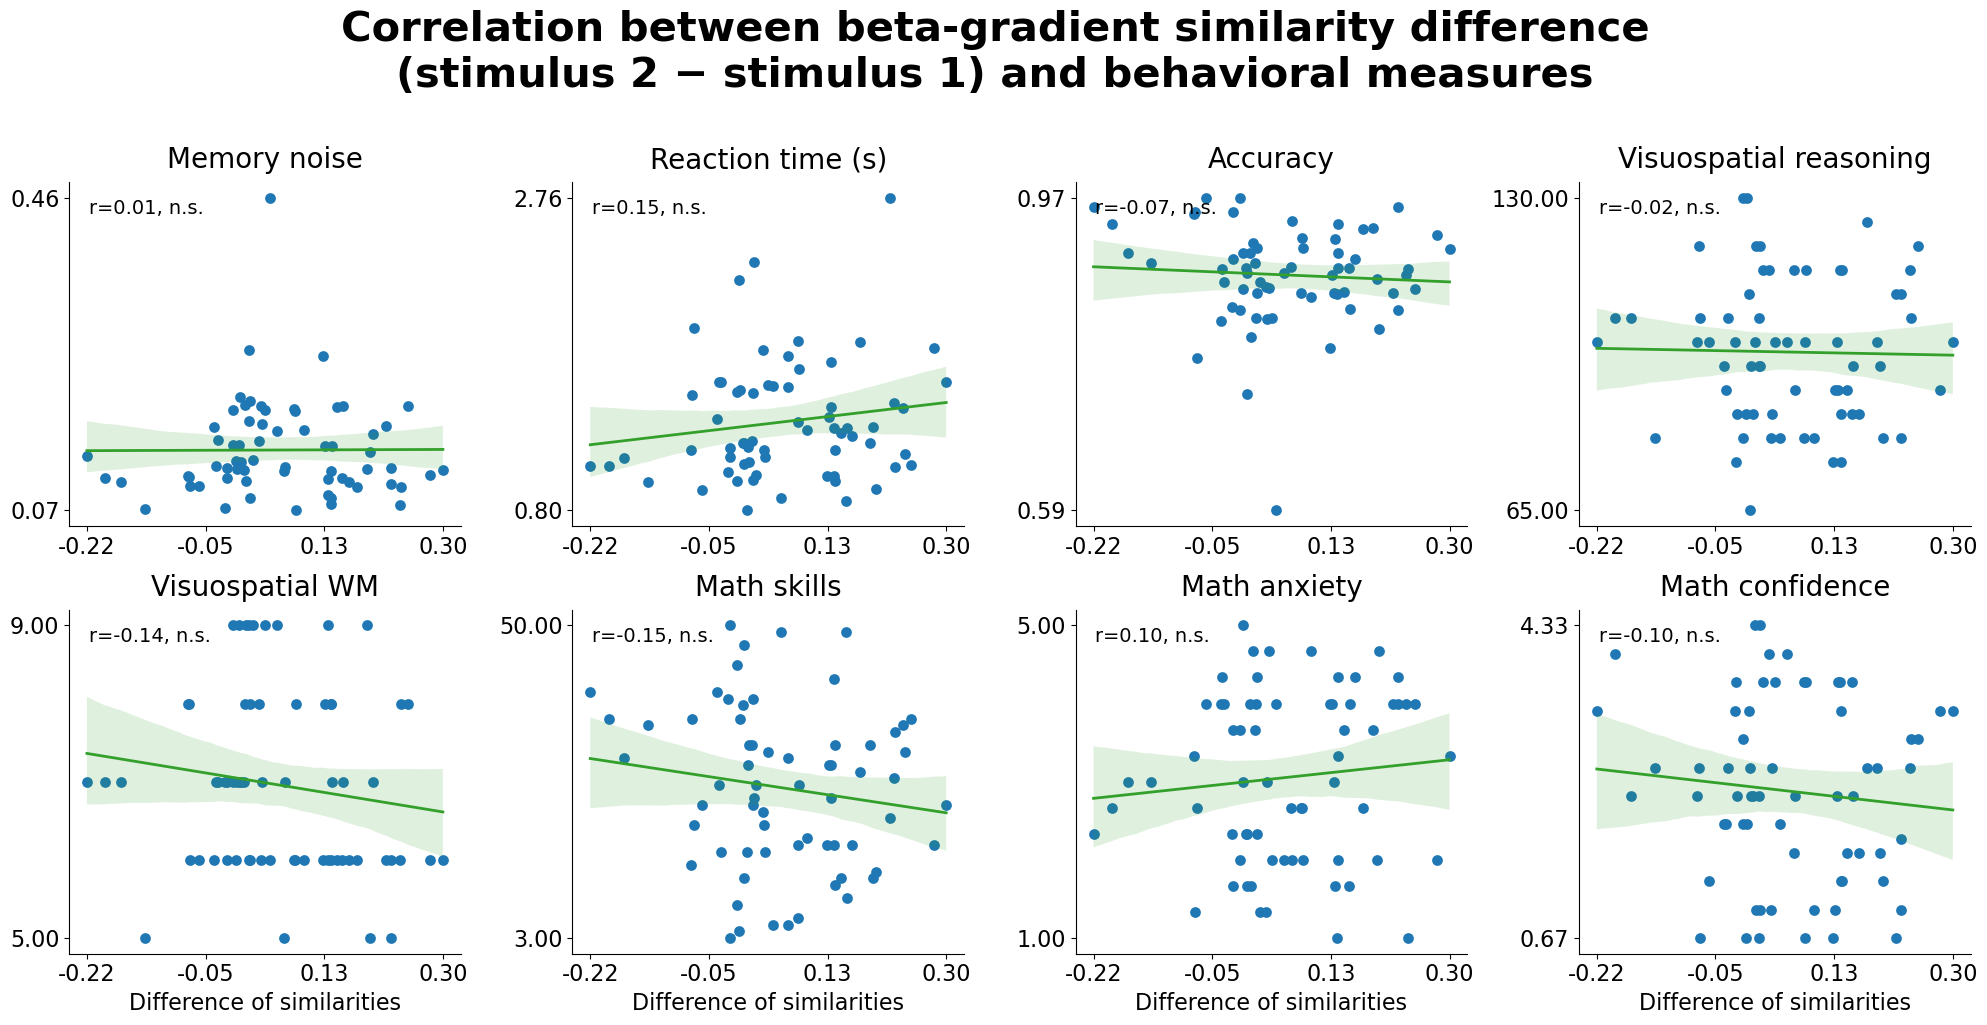

In [58]:
from scipy.stats import pearsonr, linregress
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import os.path as op

# ── style ─────────────────────────────────────────────────────────────────────
size_title = 30
size_other = 20
size_axis  = 16
colors     = ['#1f78b4', '#33a02c']

# ── x-vectors: grad-beta correlation per subject ──────────────────────────────
grad_conditions = {
    'Stimulus 1':              df_corrs['corr_1'],
    'Stimulus 2':              df_corrs['corr_2'],
    'Stimulus 2 − Stimulus 1': df_corrs['corr_2'] - df_corrs['corr_1'],
}

xlabel_map = {
    'Stimulus 1':              'Similarity',
    'Stimulus 2':              'Similarity',
    'Stimulus 2 − Stimulus 1': 'Difference of similarities',
}

behav_rows = [
    ('memory_noise_sd',  'Memory noise',      'Memory noise'),
    ('reaction_time',    'Reaction time (s)', 'Reaction time (s)'),
    ('accuracy',         'Accuracy',          'Accuracy'),
    ('me',               'Visuospatial reasoning',  'Visuospatial reasoning'),
    ('erfassungsspanne', 'Visuospatial WM',   'Visuospatial WM'),
    ('skill_score',      'Math skills',       'Math skills'),
    ('anx_mean',         'Math anxiety',      'Math anxiety'),
    ('conf_mean',        'Math confidence',   'Math confidence'),
]

# ── collect all tests ─────────────────────────────────────────────────────────
records = []
for col_idx, (grad_label, x_vec) in enumerate(grad_conditions.items()):
    for row_idx, (bvar, ylabel, ylabel_left) in enumerate(behav_rows):
        y_vec = df_comb[bvar].values
        n     = min(len(x_vec), len(y_vec))
        x_arr = x_vec.values[:n]
        y_arr = y_vec[:n]
        mask  = np.isfinite(x_arr) & np.isfinite(y_arr)
        r, p  = pearsonr(x_arr[mask], y_arr[mask])
        slope, intercept, *_ = linregress(x_arr[mask], y_arr[mask])
        records.append({
            'row':        row_idx,
            'col':        col_idx,
            'grad_label': grad_label,
            'bvar':       bvar,
            'ylabel':     ylabel_left,
            'x':          x_arr,
            'y':          y_arr,
            'mask':       mask,
            'r':          r,
            'p':          p,
            'slope':      slope,
            'intercept':  intercept,
        })

# ── FDR-BH ───────────────────────────────────────────────────────────────────
_, p_fdr, _, _ = multipletests([rec['p'] for rec in records], method='fdr_bh')
for rec, p_adj in zip(records, p_fdr):
    rec['p_fdr'] = p_adj

# ── print all correlations ────────────────────────────────────────────────────
for rec in records:
    sig_str = '**' if rec['p_fdr'] < 0.01 else ('*' if rec['p_fdr'] < 0.05 else ('†' if rec['p_fdr'] < 0.1 else 'n.s.'))
    print(f'[{rec["grad_label"]}] {rec["bvar"]}: r={rec["r"]:.3f}, p_raw={rec["p"]:.4f}, p_FDR={rec["p_fdr"]:.4f}  {sig_str}')

# ── plot only "Stimulus 2 − Stimulus 1" in 2 rows x 4 cols ───────────────────
diff_records = [rec for rec in records if rec['grad_label'] == 'Stimulus 2 − Stimulus 1']

n_rows, n_cols = 2, 4
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 10))

for i, rec in enumerate(diff_records):
    row = i // n_cols
    col = i % n_cols
    ax  = axes[row, col]

    x     = rec['x'];     y     = rec['y'];     mask  = rec['mask']
    slope = rec['slope'];  inter = rec['intercept']
    r     = rec['r'];      p_raw = rec['p'];     p_adj = rec['p_fdr']

    sig_str = '**' if p_adj < 0.01 else ('*' if p_adj < 0.05 else ('†' if p_adj < 0.1 else 'n.s.'))

    df_plot = pd.DataFrame({'x': x[mask], 'y': y[mask]})
    sns.regplot(data=df_plot, x='x', y='y', ax=ax,
                color=colors[0],
                scatter_kws=dict(s=60, alpha=1, linewidths=0),
                line_kws=dict(linewidth=2, color=colors[1]),
                ci=95)

    ax.text(0.05, 0.95, f'r={r:.2f}, {sig_str}', transform=ax.transAxes,
            fontsize=size_axis - 2, va='top', color='black')

    ax.set_title(rec['ylabel'], fontsize=size_other, pad=10)
    ax.set_xlabel('Difference of similarities' if row == 1 else '', fontsize=size_axis)
    ax.set_ylabel('')

    x_clean = x[mask]
    xt = np.linspace(x_clean.min(), x_clean.max(), 4)
    ax.set_xticks(xt)
    ax.set_xticklabels([f'{v:.2f}' for v in xt], fontsize=size_axis)

    y_clean = y[mask]
    ymin, ymax = y_clean.min(), y_clean.max()
    ax.set_yticks([ymin, ymax])
    ax.set_yticklabels([f'{ymin:.2f}', f'{ymax:.2f}'], fontsize=size_axis)

    ax.grid(False)
    sns.despine(ax=ax)

    legend = ax.get_legend()
    if legend:
        legend.remove()

fig.suptitle('Correlation between beta-gradient similarity difference\n(stimulus 2 − stimulus 1) and behavioral measures',
             fontsize=size_title, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [63]:
from scipy.stats import ttest_ind

for bvar, label in [('reaction_time', 'Reaction time'), ('accuracy', 'Accuracy')]:
    ctrl = df_comb.loc[df_comb['group'] == 0, bvar].dropna()
    dd   = df_comb.loc[df_comb['group'] == 1, bvar].dropna()
    t, p = ttest_ind(ctrl, dd)
    print(f'{label}: Control={ctrl.mean():.3f}±{ctrl.std():.3f}, DD={dd.mean():.3f}±{dd.std():.3f}, t={t:.2f}, p={p:.4f}')

Reaction time: Control=1.270±0.298, DD=1.440±0.421, t=-1.87, p=0.0656
Accuracy: Control=0.890±0.052, DD=0.866±0.067, t=1.60, p=0.1137


[Stimulus 1] memory_noise_sd  Control: r=-0.088 p_FDR=0.9299  Dyscalculia: r=0.097 p_FDR=0.8327
[Stimulus 1] reaction_time  Control: r=0.027 p_FDR=0.9299  Dyscalculia: r=-0.154 p_FDR=0.8327
[Stimulus 1] accuracy  Control: r=-0.123 p_FDR=0.9299  Dyscalculia: r=-0.081 p_FDR=0.8577
[Stimulus 1] me  Control: r=-0.093 p_FDR=0.9299  Dyscalculia: r=0.075 p_FDR=0.8577
[Stimulus 1] erfassungsspanne  Control: r=-0.069 p_FDR=0.9299  Dyscalculia: r=0.019 p_FDR=0.9339
[Stimulus 1] skill_score  Control: r=-0.100 p_FDR=0.9299  Dyscalculia: r=-0.062 p_FDR=0.8770
[Stimulus 1] anx_mean  Control: r=0.032 p_FDR=0.9299  Dyscalculia: r=0.127 p_FDR=0.8327
[Stimulus 1] conf_mean  Control: r=0.067 p_FDR=0.9299  Dyscalculia: r=-0.136 p_FDR=0.8327
[Stimulus 2] memory_noise_sd  Control: r=-0.041 p_FDR=0.9299  Dyscalculia: r=-0.047 p_FDR=0.9095
[Stimulus 2] reaction_time  Control: r=0.206 p_FDR=0.9299  Dyscalculia: r=-0.164 p_FDR=0.8327
[Stimulus 2] accuracy  Control: r=-0.251 p_FDR=0.9299  Dyscalculia: r=0.020 p_

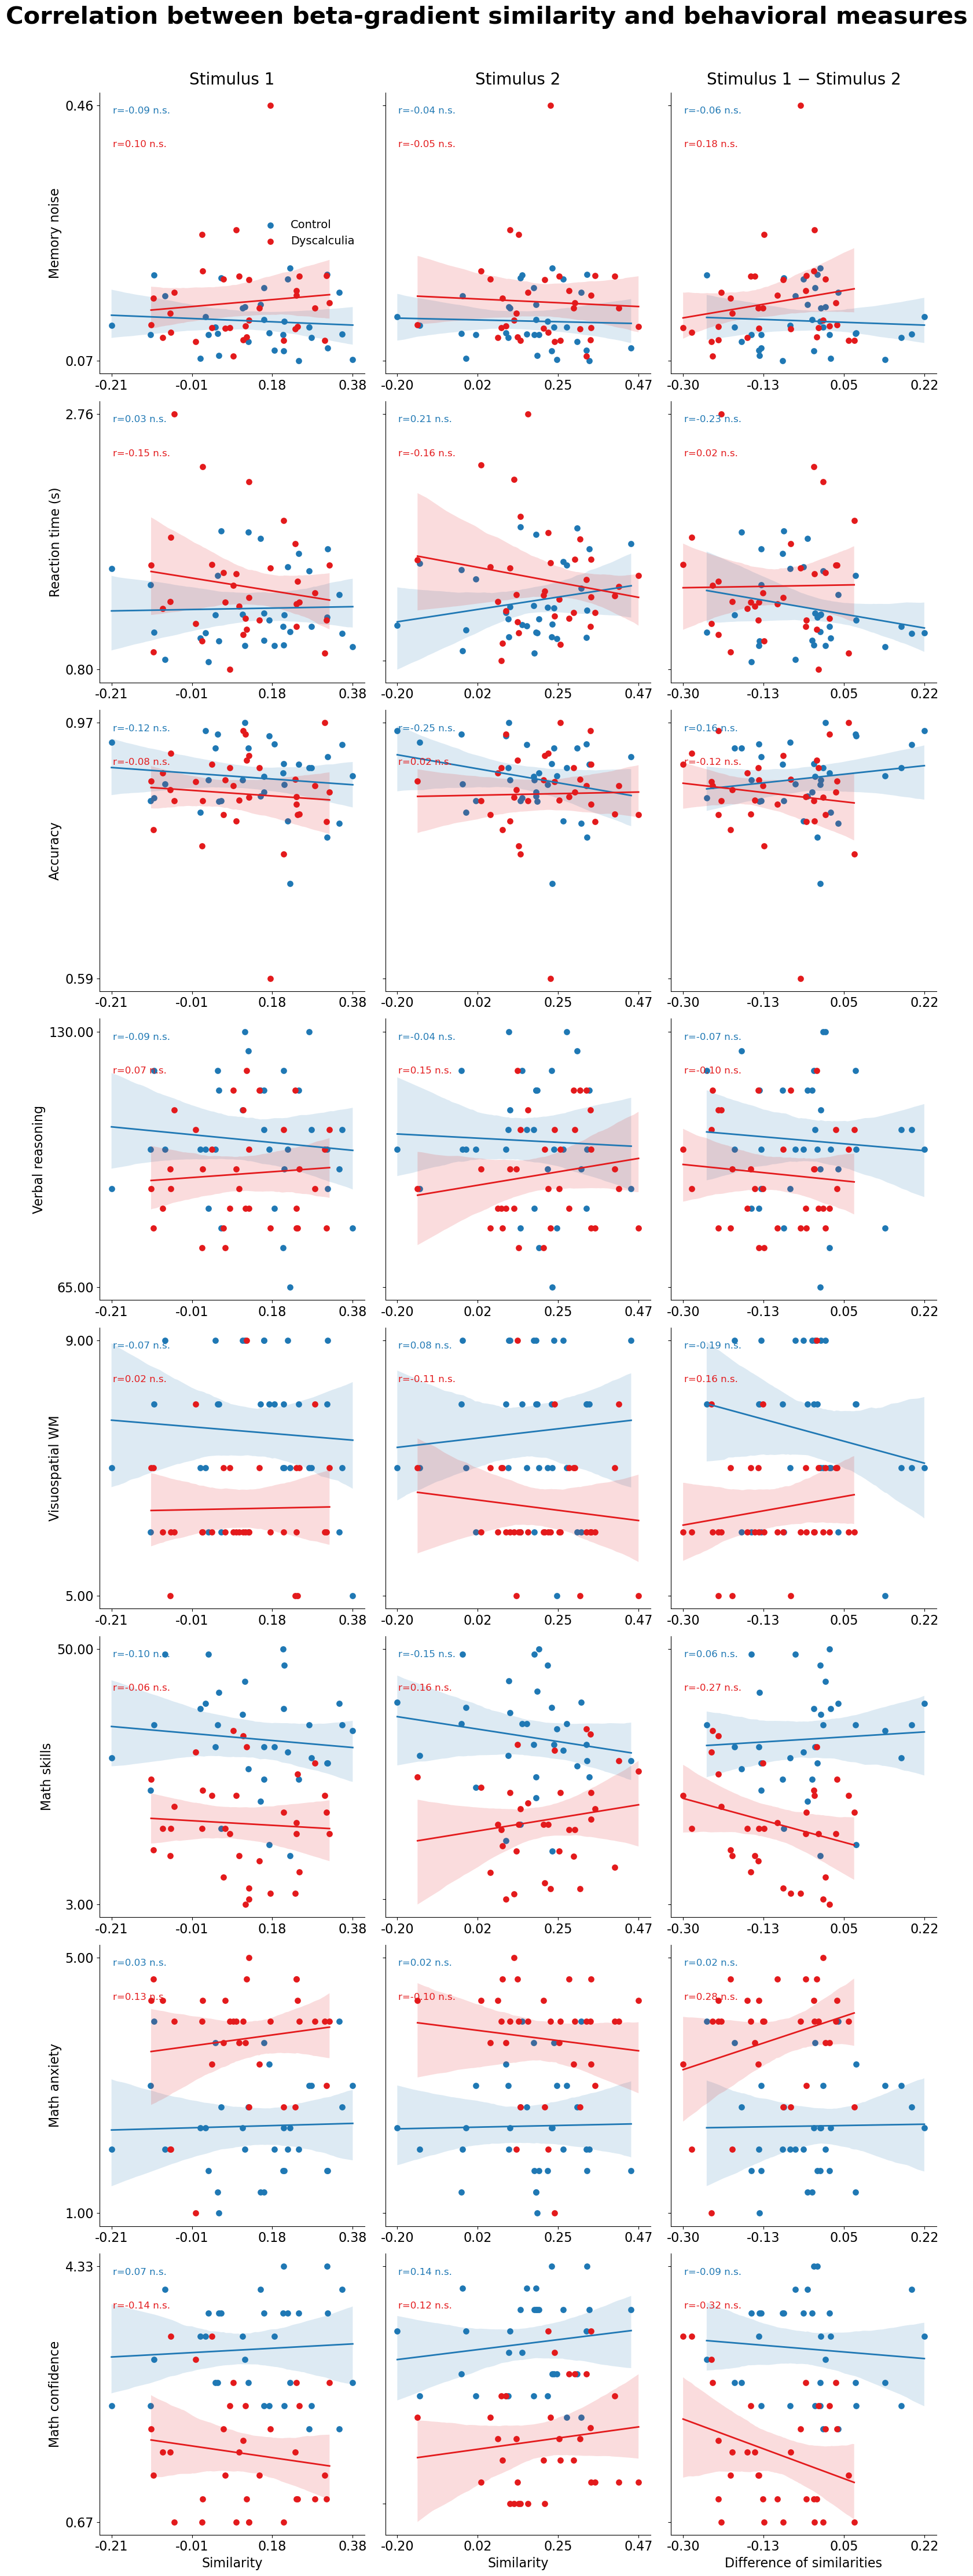

In [13]:
from scipy.stats import pearsonr, linregress
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import os.path as op

# ── style ─────────────────────────────────────────────────────────────────────
size_title = 30
size_other = 20
size_axis  = 16
group_colors = {0: '#1f78b4', 1: '#e31a1c'}
group_labels = {0: 'Control', 1: 'Dyscalculia'}

# ── x-vectors ────────────────────────────────────────────────────────────────
grad_conditions = {
    'Stimulus 1':              df_corrs['corr_1'],
    'Stimulus 2':              df_corrs['corr_2'],
    'Stimulus 1 − Stimulus 2': df_corrs['corr_1'] - df_corrs['corr_2'],
}

xlabel_map = {
    'Stimulus 1':              'Similarity',
    'Stimulus 2':              'Similarity',
    'Stimulus 1 − Stimulus 2': 'Difference of similarities',
}

behav_rows = [
    ('memory_noise_sd',  'Memory noise',      'Memory noise'),
    ('reaction_time',    'Reaction time (s)', 'Reaction time (s)'),
    ('accuracy',         'Accuracy',          'Accuracy'),
    ('me',               'Verbal reasoning',  'Verbal reasoning'),
    ('erfassungsspanne', 'Visuospatial WM',   'Visuospatial WM'),
    ('skill_score',      'Math skills',       'Math skills'),
    ('anx_mean',         'Math anxiety',      'Math anxiety'),
    ('conf_mean',        'Math confidence',   'Math confidence'),
]

group_vec = df_comb['group'].values

# ── collect all tests (per group) ────────────────────────────────────────────
records = []
for col_idx, (grad_label, x_vec) in enumerate(grad_conditions.items()):
    for row_idx, (bvar, ylabel, ylabel_left) in enumerate(behav_rows):
        y_vec = df_comb[bvar].values
        n     = min(len(x_vec), len(y_vec))
        x_arr = x_vec.values[:n]
        y_arr = y_vec[:n]
        g_arr = group_vec[:n]
        mask  = np.isfinite(x_arr) & np.isfinite(y_arr)

        group_stats = {}
        for grp in group_colors:
            gm = mask & (g_arr == grp)
            r, p = pearsonr(x_arr[gm], y_arr[gm])
            slope, intercept, *_ = linregress(x_arr[gm], y_arr[gm])
            group_stats[grp] = {
                'r': r, 'p': p,
                'slope': slope, 'intercept': intercept,
                'mask': gm,
            }

        records.append({
            'row':         row_idx,
            'col':         col_idx,
            'grad_label':  grad_label,
            'bvar':        bvar,
            'ylabel':      ylabel_left,
            'x':           x_arr,
            'y':           y_arr,
            'g':           g_arr,
            'mask':        mask,
            'group_stats': group_stats,
        })

# ── FDR-BH per group ─────────────────────────────────────────────────────────
for grp in group_colors:
    ps = [rec['group_stats'][grp]['p'] for rec in records]
    _, p_fdr, _, _ = multipletests(ps, method='fdr_bh')
    for rec, p_adj in zip(records, p_fdr):
        rec['group_stats'][grp]['p_fdr'] = p_adj

# ── plot ──────────────────────────────────────────────────────────────────────
n_rows, n_cols = len(behav_rows), len(grad_conditions)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 44), sharex=False, sharey=False)

for rec in records:
    ax   = axes[rec['row'], rec['col']]
    x    = rec['x'];  y = rec['y']
    g    = rec['g'];  mask = rec['mask']
    col  = rec['col']; row = rec['row']

    df_plot = pd.DataFrame({
        'x':     x[mask],
        'y':     y[mask],
        'group': [group_labels[v] for v in g[mask]],
    })

    for grp, gc in group_colors.items():
        label = group_labels[grp]
        df_g  = df_plot[df_plot['group'] == label]
        sns.regplot(data=df_g, x='x', y='y', ax=ax,
                    color=gc,
                    scatter_kws=dict(s=60, alpha=1, linewidths=0),
                    line_kws=dict(linewidth=2),
                    label=label,
                    ci=95)

        gs      = rec['group_stats'][grp]
        r       = gs['r']
        p_adj   = gs['p_fdr']
        sig_str = '**' if p_adj < 0.01 else ('*' if p_adj < 0.05 else ('†' if p_adj < 0.1 else 'n.s.'))
        ypos    = 0.95 - list(group_colors).index(grp) * 0.12
        ax.text(0.05, ypos, f'r={r:.2f} {sig_str}', transform=ax.transAxes,
                fontsize=size_axis - 4, va='top', color=gc)

    if row == 0:
        ax.set_title(rec['grad_label'], fontsize=size_other, pad=10)

    ax.set_xlabel(xlabel_map[rec['grad_label']] if row == n_rows - 1 else '', fontsize=size_axis)

    x_clean = x[mask]
    xt = np.linspace(x_clean.min(), x_clean.max(), 4)
    ax.set_xticks(xt)
    ax.set_xticklabels([f'{v:.2f}' for v in xt], fontsize=size_axis)

    y_clean = y[mask]
    ymin, ymax = y_clean.min(), y_clean.max()
    ax.set_yticks([ymin, ymax])
    if col == 0:
        ax.set_yticklabels([f'{ymin:.2f}', f'{ymax:.2f}'], fontsize=size_axis)
        ax.set_ylabel(rec['ylabel'], fontsize=size_axis)
    else:
        ax.set_yticklabels([])
        ax.set_ylabel('')

    ax.grid(False)
    sns.despine(ax=ax)

    if row == 0 and col == 0:
        ax.legend(frameon=False, fontsize=size_axis - 2)
    else:
        legend = ax.get_legend()
        if legend:
            legend.remove()

    print(f'[{rec["grad_label"]}] {rec["bvar"]}  '
          f'Control: r={rec["group_stats"][0]["r"]:.3f} p_FDR={rec["group_stats"][0]["p_fdr"]:.4f}  '
          f'Dyscalculia: r={rec["group_stats"][1]["r"]:.3f} p_FDR={rec["group_stats"][1]["p_fdr"]:.4f}')

fig.suptitle('Correlation between beta-gradient similarity and behavioral measures',
             fontsize=size_title, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


=== Gradient 1 ===
 Bin        t     df   p_uncorr      p_FDR  sig
----------------------------------------------
   0    1.301     63     0.1980     0.3601     
   1    1.652     63     0.1035     0.2480     
   2    1.592     63     0.1164     0.2480     
   3    1.572     63     0.1210     0.2480     
   4    1.871     63     0.0660     0.2480     
   5    1.991     63     0.0508     0.2480     
   6    1.075     63     0.2864     0.4634     
   7    0.412     63     0.6818     0.7133     
   8   -0.421     63     0.6750     0.7133     
   9   -0.926     63     0.3579     0.5113     
  10   -1.768     63     0.0820     0.2480     
  11   -1.914     63     0.0602     0.2480     
  12   -1.559     63     0.1240     0.2480     
  13   -0.850     63     0.3986     0.5122     
  14   -0.830     63     0.4098     0.5122     
  15   -1.042     63     0.3012     0.4634     
  16   -2.186     63     0.0325     0.2480     
  17   -1.964     63     0.0540     0.2480     
  18   -0.705     63 

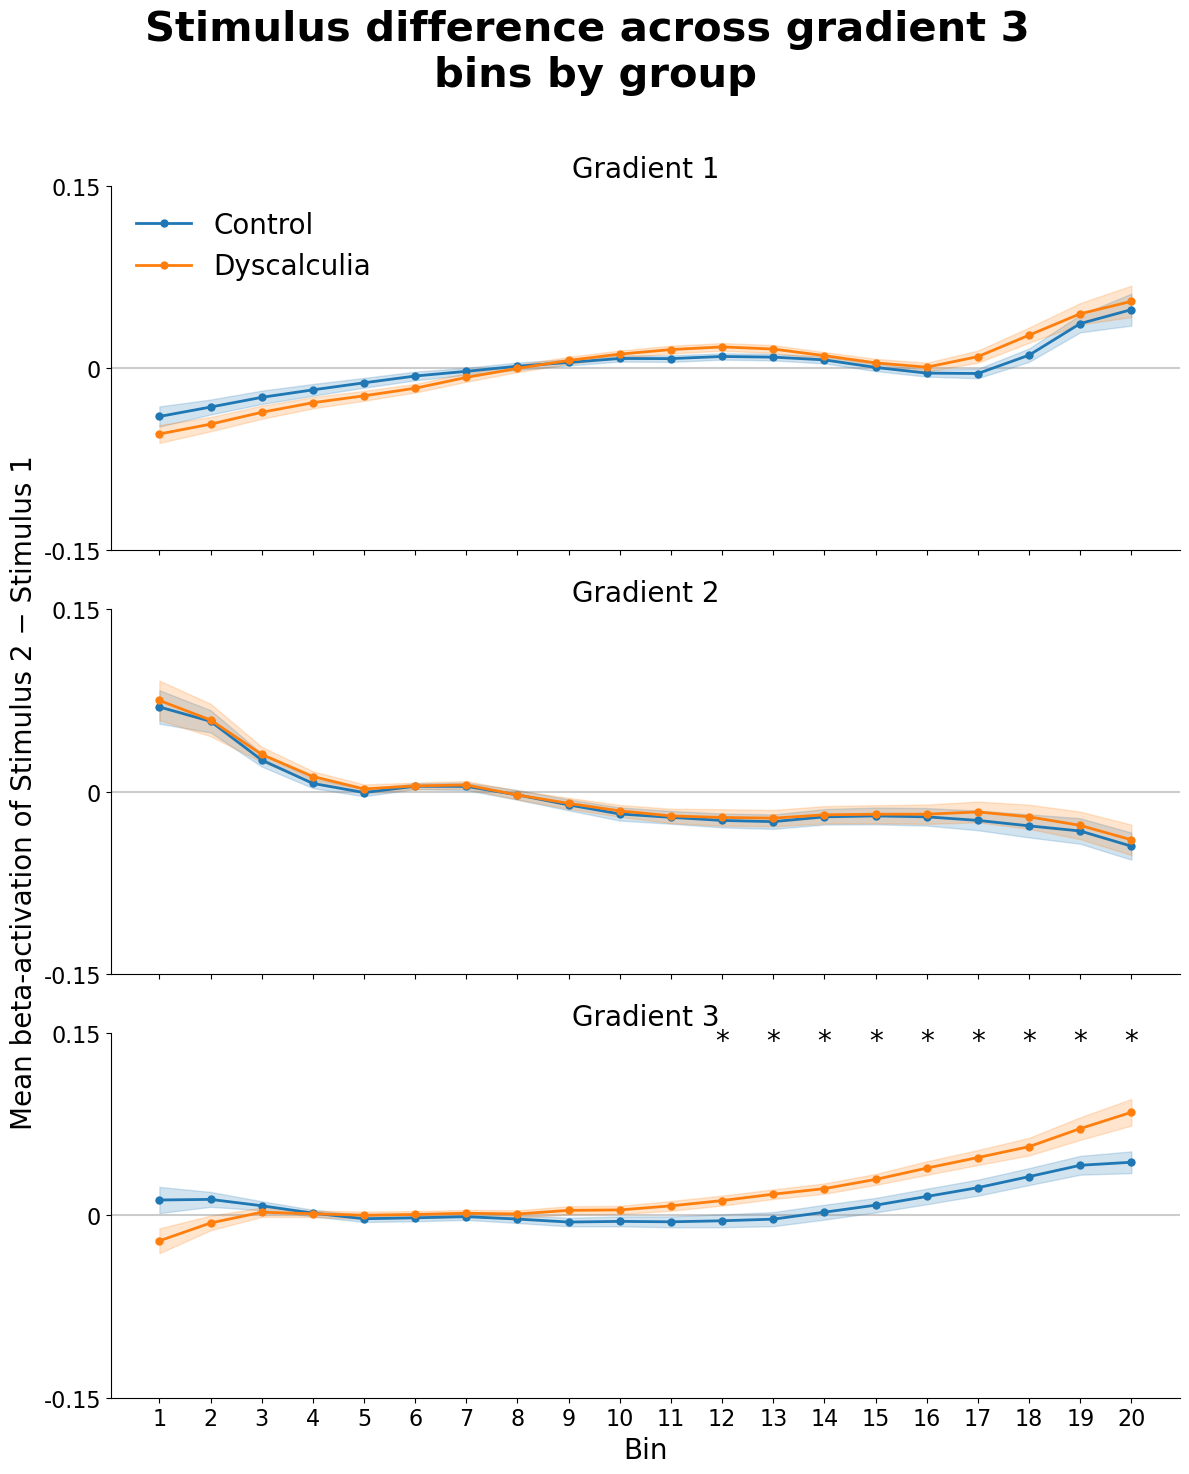

In [56]:
# diff of diff between stims and groups

from scipy.stats import shapiro, mannwhitneyu, ttest_ind
import seaborn as sns

# ---- compute per-subject stim1-stim2 difference per bin, per gradient ----
grad_nrs = [1, 2, 3]
out_dir = "/home/ubuntu/data/activation_maps_bins.glmav"

size_title = 30
size_other = 20
size_axis  = 16

diff_dfs = {}  # grad_nr -> long df with columns: subject, bin, diff, group_label

for grad_nr in grad_nrs:
    df_stim1 = pd.read_csv(op.join(out_dir, f"df_stim1_grad{grad_nr}_nan_uneven_new_{aligned}{flipped}.csv"))
    df_stim2 = pd.read_csv(op.join(out_dir, f"df_stim2_grad{grad_nr}_nan_uneven_new_{aligned}{flipped}.csv"))

    # merge on subject, compute diff per bin
    df_merged_bins = df_stim2.set_index('subject') - df_stim1.set_index('subject')
    df_merged_bins = df_merged_bins.reset_index()  # subject back as column

    # melt to long format
    long_df = df_merged_bins.melt(id_vars='subject', var_name='bin', value_name='diff')
    long_df['bin'] = long_df['bin'].str.replace('bin_', '').astype(int)

    # add group label — subject column is 'sub-01' format, strip to '01' for matching
    long_df['sub_stripped'] = long_df['subject'].str.replace('sub-', '')
    long_df['group_label'] = long_df['sub_stripped'].apply(
        lambda s: 'Control' if s in sublist_group0 else ('Dyscalculia' if s in sublist_group1 else None)
    )
    long_df = long_df.dropna(subset=['group_label', 'diff'])

    diff_dfs[grad_nr] = long_df

#print("Subjects in diff_dfs[1]:", diff_dfs[1]['subject'].nunique())
#print(diff_dfs[1].head())


group_order = ['Control', 'Dyscalculia']
color_g0 = '#1f77b4'
color_g1 = '#ff7f0e'
colors_group = {'Control': color_g0, 'Dyscalculia': color_g1}

ymin = -0.15
ymax = 0.15
bins = 20

fig, axes = plt.subplots(len(grad_nrs), 1, figsize=(12, 15), sharex=True)

for idx, grad_nr in enumerate(grad_nrs):

    ax = axes[idx]
    ax.set_title(f'Gradient {grad_nr}', fontsize=size_other)
    long_df = diff_dfs[grad_nr]

    # ---- select test per bin based on normality ----
    pvals = []
    bin_list = sorted(long_df['bin'].unique())

    for b in bin_list:
        bin_data = long_df[long_df['bin'] == b]
        g0 = bin_data.loc[bin_data['group_label'] == 'Control', 'diff'].dropna()
        g1 = bin_data.loc[bin_data['group_label'] == 'Dyscalculia', 'diff'].dropna()

        # normality check
        _, p0 = shapiro(g0) if len(g0) >= 3 else (None, 0)
        _, p1 = shapiro(g1) if len(g1) >= 3 else (None, 0)

        if p0 > 0.05 and p1 > 0.05:
            _, p = ttest_ind(g0, g1)
        else:
            _, p = ttest_ind(g0, g1)#mannwhitneyu(g0, g1, alternative='two-sided')

        pvals.append(p)

    # ---- FDR correction ----
    from statsmodels.stats.multitest import multipletests
    _, pvals_corrected, _, _ = multipletests(pvals, method='fdr_bh')

    # ---- print stats table ----
    print(f"\n=== Gradient {grad_nr} ===")
    print(f"{'Bin':>4} {'t':>8} {'df':>6} {'p_uncorr':>10} {'p_FDR':>10} {'sig':>4}")
    print("-" * 46)
    
    for b, p_raw, p_corr in zip(bin_list, pvals, pvals_corrected):
        bin_data = long_df[long_df['bin'] == b]
        g0 = bin_data.loc[bin_data['group_label'] == 'Control', 'diff'].dropna()
        g1 = bin_data.loc[bin_data['group_label'] == 'Dyscalculia', 'diff'].dropna()
        
        from scipy.stats import ttest_ind
        t_stat, _ = ttest_ind(g0, g1)
        df_val = len(g0) + len(g1) - 2  # degrees of freedom for independent samples t-test
        sig = '*' if p_corr < 0.05 else ''
        
        print(f"{b:>4} {t_stat:>8.3f} {df_val:>6} {p_raw:>10.4f} {p_corr:>10.4f} {sig:>4}")

    # ---- plot ----
    ax.grid(False)
    ax.axhline(0, color='gray', linestyle='-', linewidth=1.5, alpha=0.4)

    sns.lineplot(
        data=long_df,
        x='bin', y='diff',
        hue='group_label',
        hue_order=group_order,
        palette=colors_group,
        errorbar='se',
        marker='o',
        linewidth=2,
        markeredgewidth=0,
        ax=ax
    )

    # ---- mark significant bins ----
    y_annot = ymax * 0.88
    for b, p_corr in zip(bin_list, pvals_corrected):
        if p_corr < 0.05:
            ax.text(b, y_annot, '*', ha='center', va='bottom', fontsize=size_other, color='black')

    # ---- axes ----
    ax.set_xticks(range(bins))
    ax.set_xticklabels(range(1, bins + 1), fontsize=size_axis)
    ax.set_ylim(ymin, ymax)
    ax.set_yticks([ymin, 0, ymax])
    ax.set_yticklabels([ymin, 0, ymax], fontsize=size_axis)

    if idx == len(grad_nrs) // 2:
        ax.set_ylabel('Mean beta-activation of Stimulus 2 − Stimulus 1', fontsize=size_other)
    else:
        ax.set_ylabel('')

    ax.set_xlabel('')
    sns.despine(ax=ax)

    if idx == 0:
        ax.legend(title='', frameon=False, fontsize=size_other)
    else:
        ax.get_legend().remove()

axes[-1].set_xlabel('Bin', fontsize=size_other)

fig.suptitle(
    'Stimulus difference across gradient 3 \nbins by group',
    fontsize=size_title, weight='bold', y=0.98
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


=== Control ===
 Bin        t      p_raw      p_FDR  sig
----------------------------------------
   1   -1.180     0.2469     0.4180     
   2   -2.162     0.0384     0.1098     
   3   -2.171     0.0377     0.1098     
   4   -0.695     0.4924     0.5953     
   5    1.006     0.3224     0.4960     
   6    0.673     0.5060     0.5953     
   7    0.377     0.7090     0.7090     
   8    0.917     0.3665     0.5235     
   9    1.531     0.1358     0.3396     
  10    1.198     0.2400     0.4180     
  11    1.170     0.2508     0.4180     
  12    0.824     0.4160     0.5547     
  13    0.522     0.6054     0.6727     
  14   -0.442     0.6616     0.6965     
  15   -1.414     0.1672     0.3716     
  16   -2.445     0.0204     0.0815    †
  17   -3.464     0.0016     0.0079   **
  18   -4.590     0.0001     0.0005   **
  19   -5.340     0.0000     0.0002   **
  20   -4.898     0.0000     0.0003   **

=== Dyscalculia ===
 Bin        t      p_raw      p_FDR  sig
-------------------

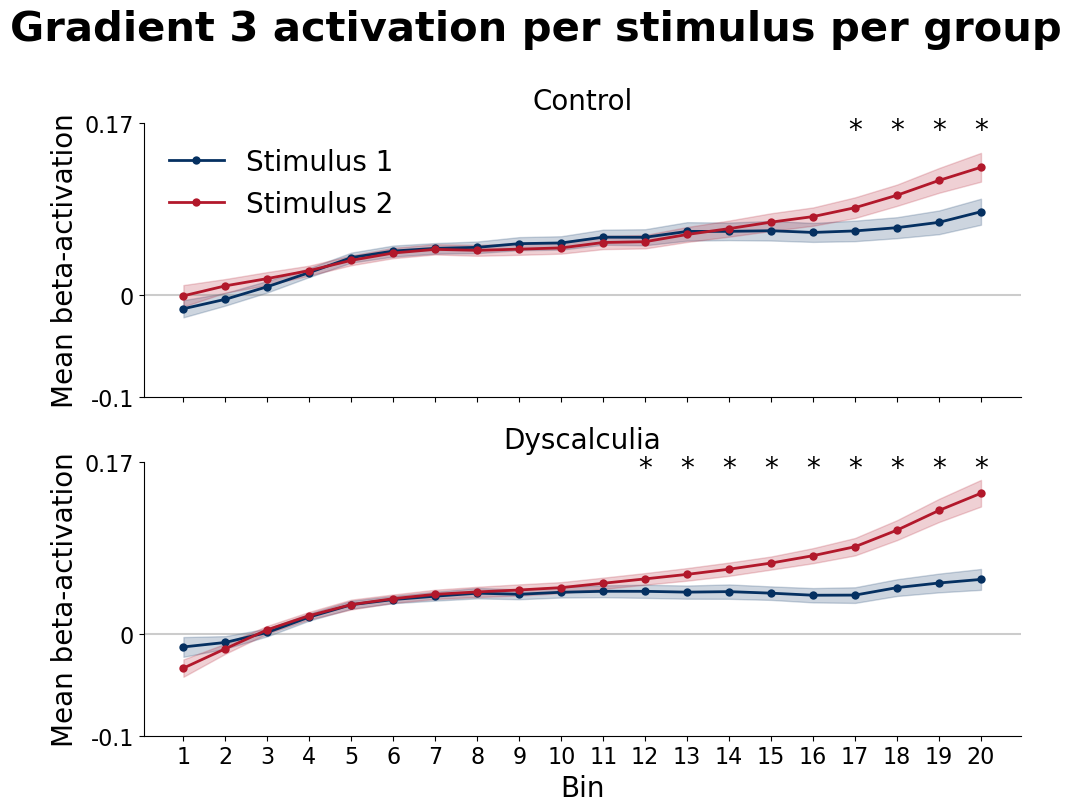

In [14]:
# ---- load stim1 and stim2 activation for grad 3, add group labels ----
import seaborn as sns

size_title = 30
size_other = 20
size_axis  = 16

grad_nr_plot = 3

df_stim1 = pd.read_csv(op.join(out_dir, f"df_stim1_grad{grad_nr_plot}_nan_uneven_new_{aligned}{flipped}.csv"))
df_stim2 = pd.read_csv(op.join(out_dir, f"df_stim2_grad{grad_nr_plot}_nan_uneven_new_{aligned}{flipped}.csv"))

def add_group(df):
    df = df.copy()
    df['sub_stripped'] = df['subject'].str.replace('sub-', '')
    df['group_label'] = df['sub_stripped'].apply(
        lambda s: 'Control' if s in sublist_group0 else ('Dyscalculia' if s in sublist_group1 else None)
    )
    df = df.drop(columns=['sub_stripped'])
    return df.dropna(subset=['group_label'])

def melt_stim(df, stim_label):
    long = df.melt(id_vars=['subject', 'group_label'], var_name='bin', value_name='mean_activation')
    long['bin'] = long['bin'].str.replace('bin_', '').astype(int)
    long['stimulus'] = stim_label
    return long

df_stim1 = add_group(df_stim1)
df_stim2 = add_group(df_stim2)

long_stim1 = melt_stim(df_stim1, 'Stimulus 1')
long_stim2 = melt_stim(df_stim2, 'Stimulus 2')
long_both  = pd.concat([long_stim1, long_stim2]).dropna(subset=['mean_activation'])

# ---- plot ----
from scipy.stats import ttest_rel
from statsmodels.stats.multitest import multipletests

color_stim1  = '#053061'
color_stim2  = '#b2182b'
group_order  = ['Control', 'Dyscalculia']
stim_palette = {'Stimulus 1': color_stim1, 'Stimulus 2': color_stim2}

ymin_act = -0.1
ymax_act =  0.17
bins     = 20

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True, sharey=True)

for idx, grp in enumerate(group_order):
    ax     = axes[idx]
    grp_df = long_both[long_both['group_label'] == grp]

    # ---- paired t-test per bin + FDR ----
    bin_list = sorted(grp_df['bin'].unique())
    pvals = []

    for b in bin_list:
        s1 = grp_df[(grp_df['bin'] == b) & (grp_df['stimulus'] == 'Stimulus 1')]\
            .set_index('subject')['mean_activation']
        s2 = grp_df[(grp_df['bin'] == b) & (grp_df['stimulus'] == 'Stimulus 2')]\
            .set_index('subject')['mean_activation']
        common = s1.index.intersection(s2.index)
        _, p = ttest_rel(s1.loc[common].dropna(), s2.loc[common].dropna())
        pvals.append(p)

    _, pvals_corrected, _, _ = multipletests(pvals, method='fdr_bh')

    # ---- print stats table ----
    print(f"\n=== {grp} ===")
    print(f"{'Bin':>4} {'t':>8} {'p_raw':>10} {'p_FDR':>10} {'sig':>4}")
    print("-" * 40)
    for b, p_raw, p_corr in zip(bin_list, pvals, pvals_corrected):
        s1 = grp_df[(grp_df['bin'] == b) & (grp_df['stimulus'] == 'Stimulus 1')]\
            .set_index('subject')['mean_activation']
        s2 = grp_df[(grp_df['bin'] == b) & (grp_df['stimulus'] == 'Stimulus 2')]\
            .set_index('subject')['mean_activation']
        common = s1.index.intersection(s2.index)
        t_stat, _ = ttest_rel(s1.loc[common].dropna(), s2.loc[common].dropna())
        sig = '**' if p_corr < 0.01 else ('*' if p_corr < 0.05 else ('†' if p_corr < 0.1 else ''))
        print(f"{b+1:>4} {t_stat:>8.3f} {p_raw:>10.4f} {p_corr:>10.4f} {sig:>4}")


    # ---- plot ----
    ax.grid(False)
    ax.axhline(0, color='gray', linestyle='-', linewidth=1.5, alpha=0.4)

    sns.lineplot(
        data=grp_df,
        x='bin', y='mean_activation',
        hue='stimulus',
        hue_order=['Stimulus 1', 'Stimulus 2'],
        palette=stim_palette,
        errorbar='se',
        marker='o',
        linewidth=2,
        markeredgewidth=0,
        ax=ax
    )

    # ---- mark significant bins ----
    y_annot = ymax_act * 0.88
    for b, p_corr in zip(bin_list, pvals_corrected):
        if p_corr < 0.05:
            ax.text(b, y_annot, '*', ha='center', va='bottom', fontsize=size_other, color='black')

    ax.set_title(grp, fontsize=size_other, pad=10)
    ax.set_xticks(range(bins))
    ax.set_xticklabels(range(1, bins + 1), fontsize=size_axis)
    ax.set_ylim(ymin_act, ymax_act)
    ax.set_yticks([ymin_act, 0, ymax_act])
    ax.set_yticklabels([ymin_act, 0, ymax_act], fontsize=size_axis)
    ax.set_ylabel('Mean beta-activation', fontsize=size_other)
    ax.set_xlabel('')
    sns.despine(ax=ax)
    if idx == 0:
        ax.legend(title='', frameon=False, fontsize=size_other)
    else:
        ax.get_legend().remove()
        
axes[-1].set_xlabel('Bin', fontsize=size_other)
fig.suptitle(f'Gradient {grad_nr_plot} activation per stimulus per group',
             fontsize=size_title, weight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [11]:
print(long_both.groupby('group_label')['subject'].nunique())

group_label
Control        32
Dyscalculia    33
Name: subject, dtype: int64


In [26]:
diff.item()

0.06774558353817803

In [51]:
diffs= {'sub': [],
        'group': [],
        'diff': []}

for sub in sublist_group0:
    diff = df_corrs[df_corrs['sub'] == sub]['corr_1'].item() - df_corrs[df_corrs['sub'] == sub]['corr_2'].item()
    diffs['sub'].append(sub)
    diffs['diff'].append(diff)
    diffs['group'].append(0)
for sub in sublist_group1:
    diff = df_corrs[df_corrs['sub'] == sub]['corr_1'].item() - df_corrs[df_corrs['sub'] == sub]['corr_2'].item()
    diffs['sub'].append(sub)
    diffs['diff'].append(diff)
    diffs['group'].append(1)


df_diffs_group = pd.DataFrame(diffs)


In [41]:
df_corrs

,sub,corr_1,pval_1,corr_2,pval_2
0,01,0.047636,7.135346e-11,-0.022604,1.991513e-03
1,02,0.123652,1.535541e-64,0.209522,2.177537e-184
2,04,0.109485,1.251272e-50,0.336850,0.000000e+00
3,05,-0.210401,4.797113e-186,-0.139427,8.692402e-82
4,06,0.115583,1.390049e-56,0.100960,1.667738e-43
...,...,...,...,...,...
57,60,0.173474,2.356312e-126,0.101413,5.657560e-44
58,61,-0.115585,1.131672e-56,0.018063,1.347754e-02
59,62,0.122040,5.192721e-63,0.298384,0.000000e+00
60,63,0.050340,5.673012e-12,0.188395,5.192985e-149


In [43]:
sublist_group1

['02',
 '04',
 '06',
 '08',
 '11',
 '13',
 '16',
 '17',
 '22',
 '23',
 '25',
 '26',
 '27',
 '29',
 '32',
 '33',
 '34',
 '37',
 '38',
 '39',
 '40',
 '41',
 '42',
 '43',
 '44',
 '45',
 '46',
 '47',
 '48',
 '49',
 '50',
 '51',
 '56']

Shapiro-Wilk Control: W=0.969, p=0.465
Shapiro-Wilk Dyscalculia: W=0.954, p=0.177

Using: t-test_ind
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Control vs. Dyscalculia: t-test independent samples, P_val:6.298e-03 t=-2.827e+00


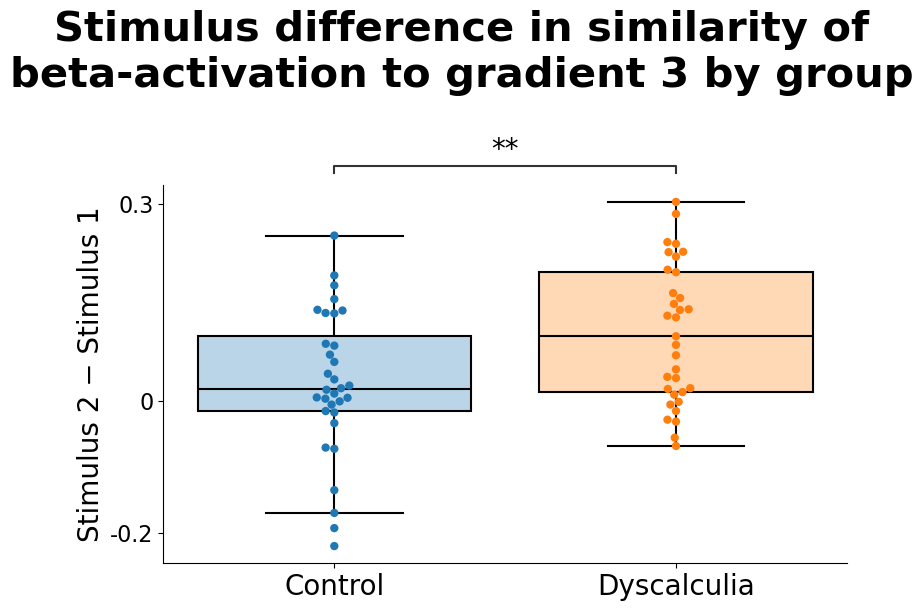

In [52]:
# diff of diff --> diff per sub between similarity and then diff in that between groups

import matplotlib.colors as mcolors
from statannotations.Annotator import Annotator
from scipy.stats import shapiro

size_title = 30
size_other = 20
size_axis = 16

color_g0 = '#1f77b4'
color_g1 = '#ff7f0e'
colors = [color_g0, color_g1]
group_order = ['Control', 'Dyscalculia']

diffs= {'sub': [],
        'group': [],
        'diff': []}

for sub in sublist_group0:
    diff = df_corrs[df_corrs['sub'] == sub]['corr_2'].item() - df_corrs[df_corrs['sub'] == sub]['corr_1'].item()
    diffs['sub'].append(sub)
    diffs['diff'].append(diff)
    diffs['group'].append('Control')
for sub in sublist_group1:
    diff = df_corrs[df_corrs['sub'] == sub]['corr_2'].item() - df_corrs[df_corrs['sub'] == sub]['corr_1'].item()
    diffs['sub'].append(sub)
    diffs['diff'].append(diff)
    diffs['group'].append('Dyscalculia')


df_diffs_group = pd.DataFrame(diffs)

# ---- select statistical test based on normality ----
normality_passed = True
for grp in group_order:
    stat, p = shapiro(df_diffs_group.loc[df_diffs_group['group'] == grp, 'diff'])
    print(f"Shapiro-Wilk {grp}: W={stat:.3f}, p={p:.3f}")
    if p <= 0.05:
        normality_passed = False

stat_test = 'Mann-Whitney' if normality_passed==False else 't-test_ind'
print(f"\nUsing: {stat_test}")

fig, ax = plt.subplots(figsize=(8, 6))

# ---- boxplot ----
bp = sns.boxplot(
    data=df_diffs_group, x='group', y='diff',
    order=group_order,
    hue='group', hue_order=group_order, legend=False,
    palette=colors,
    showfliers=False,
    linecolor='black',
    linewidth=1.5,
    ax=ax,
)

# ---- set box fill alpha manually ----
for i, patch in enumerate(ax.patches):
    r, g, b, _ = mcolors.to_rgba(colors[i])
    patch.set_facecolor((r, g, b, 0.3))
    patch.set_edgecolor('black')

# ---- swarmplot ----
sns.swarmplot(
    data=df_diffs_group, x='group', y='diff',
    order=group_order,
    hue='group', hue_order=group_order, legend=False,
    palette=colors,
    alpha=1, size=6,
    ax=ax,
)

# ---- axes ----
ax.set_xlabel('', fontsize=size_other)
ax.set_ylabel(f'Stimulus 2 − Stimulus 1', fontsize=size_other)
yticks = [-0.2, 0, 0.3]
ax.set_yticks(yticks)
ax.set_yticklabels(yticks, fontsize=size_axis)
ax.tick_params(axis='x', labelsize=size_other)
ax.tick_params(axis='y', labelsize=size_axis)

# ---- styling ----
ax.grid(False)
sns.despine(ax=ax)

# ---- title ----
fig.suptitle(
    f'Stimulus difference in similarity of\nbeta-activation to gradient {grad_nr} by group',
    fontsize=size_title, weight='bold', y=1.01
)

# ---- stats annotation ----
pairs = [('Control', 'Dyscalculia')]
annotator = Annotator(ax, pairs, data=df_diffs_group, x='group', y='diff', order=group_order)
annotator.configure(test=stat_test, text_format='star', loc='outside', fontsize=size_other)
annotator.apply_test()
annotator.annotate()

plt.tight_layout()
plt.show()


In [46]:
for sub in sublist_group0:
    rows = df_corrs[df_corrs['sub'] == sub]
    if len(rows) != 1:
        print(f"Group 0 sub {sub}: {len(rows)} rows found")

for sub in sublist_group1:
    rows = df_corrs[df_corrs['sub'] == sub]
    if len(rows) != 1:
        print(f"Group 1 sub {sub}: {len(rows)} rows found")

Group 0 sub 14: 0 rows found
Group 0 sub 65: 0 rows found
Group 0 sub 66: 0 rows found


Shapiro-Wilk diff Control: W=0.969, p=0.465
Shapiro-Wilk diff Dyscalculia: W=0.954, p=0.177
Using for diff plot: t-test_ind

Shapiro-Wilk overall Control: W=0.964, p=0.347
Shapiro-Wilk overall Dyscalculia: W=0.977, p=0.688
Using for overall plot: t-test_ind

Shapiro Stimulus 1 Control: p=0.490
Shapiro Stimulus 1 Dyscalculia: p=0.215
Using: t-test_ind

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Control vs. Dyscalculia: t-test independent samples, P_val:3.689e-01 t=9.051e-01
Shapiro Stimulus 2 Control: p=0.186
Shapiro Stimulus 2 Dyscalculia: p=0.655
Using: t-test_ind

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Control vs. Dyscalculia: t-test independent samples, P_val:1.851e-01 t=-1.340e+00
p-va

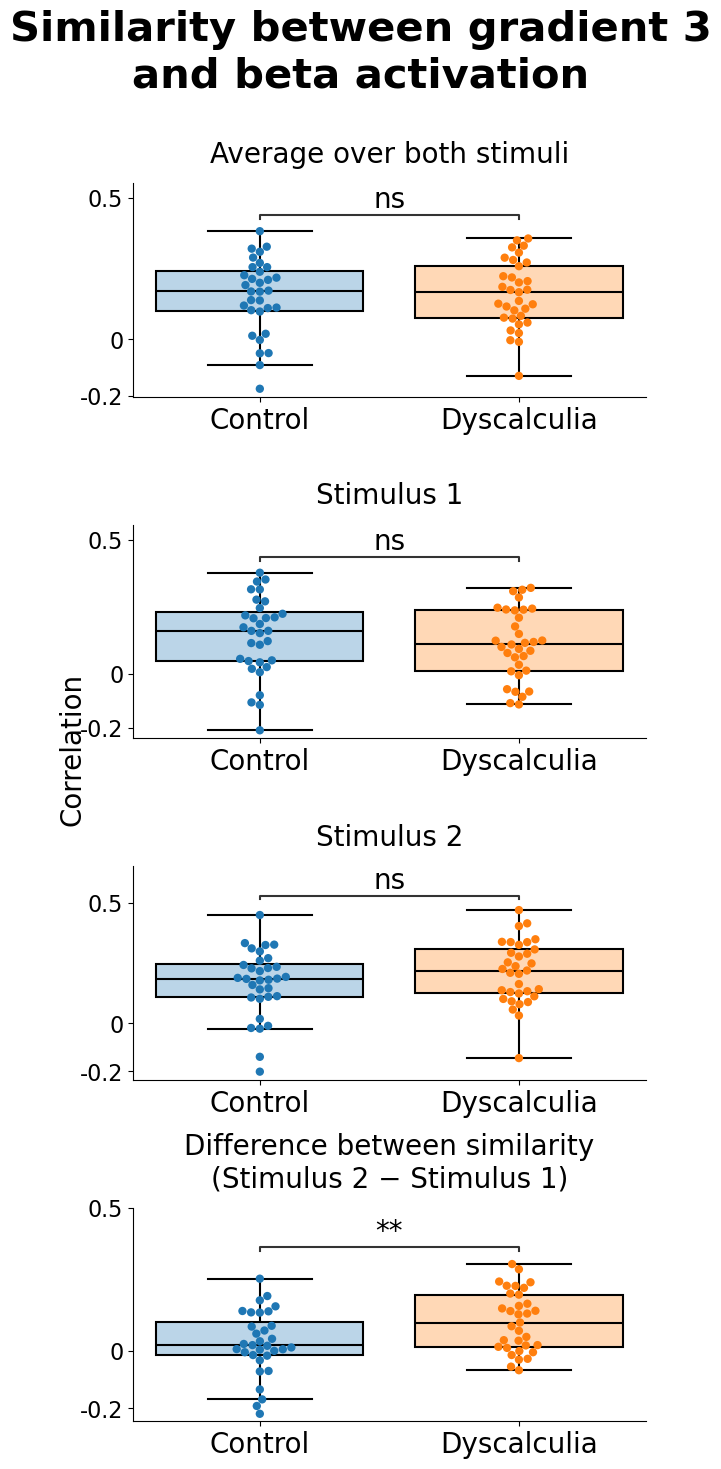

In [55]:
import matplotlib.colors as mcolors
from statannotations.Annotator import Annotator
from scipy.stats import shapiro
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

size_title = 30
size_other = 20
size_axis  = 16

color_g0     = '#1f77b4'
color_g1     = '#ff7f0e'
colors       = [color_g0, color_g1]
group_order  = ['Control', 'Dyscalculia']
colors_group = [color_g0, color_g1]

# ---- add group label to df_corrs ----
df_corrs['group_label'] = df_corrs['sub'].apply(
    lambda s: 'Control' if s in sublist_group0 else ('Dyscalculia' if s in sublist_group1 else None)
)
df_corrs_valid = df_corrs.dropna(subset=['group_label'])

# ---- reshape to long ----
df_long_corrs = pd.melt(
    df_corrs_valid,
    id_vars=['sub', 'group_label'],
    value_vars=['corr_1', 'corr_2'],
    var_name='stimulus',
    value_name='correlation'
)
df_long_corrs['stimulus'] = df_long_corrs['stimulus'].map({
    'corr_1': 'Stimulus 1',
    'corr_2': 'Stimulus 2'
})

# ---- build diff df (Stimulus 2 - Stimulus 1) ----
diffs = {'sub': [], 'group': [], 'diff': []}
for sub in sublist_group0:
    diff = df_corrs[df_corrs['sub'] == sub]['corr_2'].item() - df_corrs[df_corrs['sub'] == sub]['corr_1'].item()
    diffs['sub'].append(sub)
    diffs['diff'].append(diff)
    diffs['group'].append('Control')
for sub in sublist_group1:
    diff = df_corrs[df_corrs['sub'] == sub]['corr_2'].item() - df_corrs[df_corrs['sub'] == sub]['corr_1'].item()
    diffs['sub'].append(sub)
    diffs['diff'].append(diff)
    diffs['group'].append('Dyscalculia')
df_diffs_group = pd.DataFrame(diffs)

# ---- build overall (mean across stim) df ----
df_corrs_valid['corr_mean'] = (df_corrs_valid['corr_1'] + df_corrs_valid['corr_2']) / 2
df_overall = df_corrs_valid[['sub', 'group_label', 'corr_mean']].copy()

# ---- normality checks ----
normality_passed_diff = True
for grp in group_order:
    stat, p = shapiro(df_diffs_group.loc[df_diffs_group['group'] == grp, 'diff'])
    print(f"Shapiro-Wilk diff {grp}: W={stat:.3f}, p={p:.3f}")
    if p <= 0.05:
        normality_passed_diff = False
stat_test_diff = 'Mann-Whitney' if not normality_passed_diff else 't-test_ind'
print(f"Using for diff plot: {stat_test_diff}\n")

normality_passed_overall = True
for grp in group_order:
    stat, p = shapiro(df_overall.loc[df_overall['group_label'] == grp, 'corr_mean'])
    print(f"Shapiro-Wilk overall {grp}: W={stat:.3f}, p={p:.3f}")
    if p <= 0.05:
        normality_passed_overall = False
stat_test_overall = 'Mann-Whitney' if not normality_passed_overall else 't-test_ind'
print(f"Using for overall plot: {stat_test_overall}\n")

# ---- 4 rows, 1 col with shared y axis ----
fig, axes = plt.subplots(4, 1, figsize=(6, 14.5), sharey=False)

stim_labels = ['Stimulus 1', 'Stimulus 2']

# shared y limits for the correlation plots (rows 0, 1, 2)
corr_yticks = [-0.2, 0, 0.5]

for idx, stim in enumerate(stim_labels):
    ax     = axes[idx + 1]
    df_sub = df_long_corrs[df_long_corrs['stimulus'] == stim]

    normality_passed = True
    for grp in group_order:
        _, p_sw = shapiro(df_sub.loc[df_sub['group_label'] == grp, 'correlation'].dropna())
        print(f"Shapiro {stim} {grp}: p={p_sw:.3f}")
        if p_sw <= 0.05:
            normality_passed = False
    stat_test = 't-test_ind' if normality_passed else 'Mann-Whitney'
    print(f"Using: {stat_test}\n")

    sns.boxplot(
        data=df_sub, x='group_label', y='correlation',
        order=group_order,
        hue='group_label', hue_order=group_order, legend=False,
        palette=colors_group, showfliers=False,
        linecolor='black', linewidth=1.5, ax=ax,
    )
    for i, patch in enumerate(ax.patches):
        r, g, b, _ = mcolors.to_rgba(colors_group[i])
        patch.set_facecolor((r, g, b, 0.3))
        patch.set_edgecolor('black')

    sns.swarmplot(
        data=df_sub, x='group_label', y='correlation',
        order=group_order,
        hue='group_label', hue_order=group_order, legend=False,
        palette=colors_group, alpha=1, size=6, ax=ax,
    )

    ax.set_yticks(corr_yticks)
    ax.set_yticklabels(corr_yticks, fontsize=size_axis)
    ax.set_title(stim, fontsize=size_other, pad=15)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', labelsize=size_other)
    ax.tick_params(axis='y', labelsize=size_axis)
    ax.grid(False)
    sns.despine(ax=ax)

    pairs = [('Control', 'Dyscalculia')]
    annotator = Annotator(ax, pairs, data=df_sub, x='group_label', y='correlation', order=group_order)
    annotator.configure(test=stat_test, text_format='star', loc='inside', fontsize=size_other)
    annotator.apply_test()
    annotator.annotate()

# ---- diff plot (row 3) ----
ax_diff = axes[3]

sns.boxplot(
    data=df_diffs_group, x='group', y='diff',
    order=group_order,
    hue='group', hue_order=group_order, legend=False,
    palette=colors, showfliers=False,
    linecolor='black', linewidth=1.5, ax=ax_diff,
)
for i, patch in enumerate(ax_diff.patches):
    r, g, b, _ = mcolors.to_rgba(colors[i])
    patch.set_facecolor((r, g, b, 0.3))
    patch.set_edgecolor('black')

sns.swarmplot(
    data=df_diffs_group, x='group', y='diff',
    order=group_order,
    hue='group', hue_order=group_order, legend=False,
    palette=colors, alpha=1, size=6, ax=ax_diff,
)

ax_diff.set_yticks(corr_yticks)
ax_diff.set_yticklabels(corr_yticks, fontsize=size_axis)
ax_diff.set_xlabel('')
ax_diff.set_ylabel('')
ax_diff.set_title('Difference between similarity\n(Stimulus 2 − Stimulus 1)', fontsize=size_other, pad=15)
ax_diff.tick_params(axis='x', labelsize=size_other)
ax_diff.tick_params(axis='y', labelsize=size_axis)
ax_diff.grid(False)
sns.despine(ax=ax_diff)

pairs = [('Control', 'Dyscalculia')]
annotator = Annotator(ax_diff, pairs, data=df_diffs_group, x='group', y='diff', order=group_order)
annotator.configure(test=stat_test_diff, text_format='star', loc='inside', fontsize=size_other)
annotator.apply_test()
annotator.annotate()

# ---- overall plot (row 0) ----
ax_overall = axes[0]

sns.boxplot(
    data=df_overall, x='group_label', y='corr_mean',
    order=group_order,
    hue='group_label', hue_order=group_order, legend=False,
    palette=colors, showfliers=False,
    linecolor='black', linewidth=1.5, ax=ax_overall,
)
for i, patch in enumerate(ax_overall.patches):
    r, g, b, _ = mcolors.to_rgba(colors[i])
    patch.set_facecolor((r, g, b, 0.3))
    patch.set_edgecolor('black')

sns.swarmplot(
    data=df_overall, x='group_label', y='corr_mean',
    order=group_order,
    hue='group_label', hue_order=group_order, legend=False,
    palette=colors, alpha=1, size=6, ax=ax_overall,
)

ax_overall.set_yticks(corr_yticks)
ax_overall.set_yticklabels(corr_yticks, fontsize=size_axis)
ax_overall.set_xlabel('')
ax_overall.set_ylabel('')
ax_overall.set_title('Average over both stimuli', fontsize=size_other, pad=15)
ax_overall.tick_params(axis='x', labelsize=size_other)
ax_overall.tick_params(axis='y', labelsize=size_axis)
ax_overall.grid(False)
sns.despine(ax=ax_overall)

pairs = [('Control', 'Dyscalculia')]
annotator = Annotator(ax_overall, pairs, data=df_overall, x='group_label', y='corr_mean', order=group_order)
annotator.configure(test=stat_test_overall, text_format='star', loc='inside', fontsize=size_other)
annotator.apply_test()
annotator.annotate()

# ---- shared y label in the middle of the figure ----
fig.text(0.02, 0.5, 'Correlation', va='center', ha='center',
         rotation='vertical', fontsize=size_other)

fig.suptitle(
    f'Similarity between gradient 3\nand beta activation',
    fontsize=size_title, weight='bold', y=1.01
)

plt.tight_layout()
plt.subplots_adjust(left=0.12)  # make room for the shared y label
plt.show()

Shapiro-Wilk on difference: p=0.292 → using t-test_paired
Using for diff plot: t-test_ind
Using for overall plot: t-test_ind
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Control vs. Dyscalculia: t-test independent samples, P_val:6.298e-03 t=-2.827e+00
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Control vs. Dyscalculia: t-test independent samples, P_val:3.689e-01 t=9.051e-01
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Control vs. Dyscalculia: t-test independent samples, P_val:1.851e-01 t=-1.340e+00
p-value annotation legend:
      ns: 5.00e-02 < p <= 1

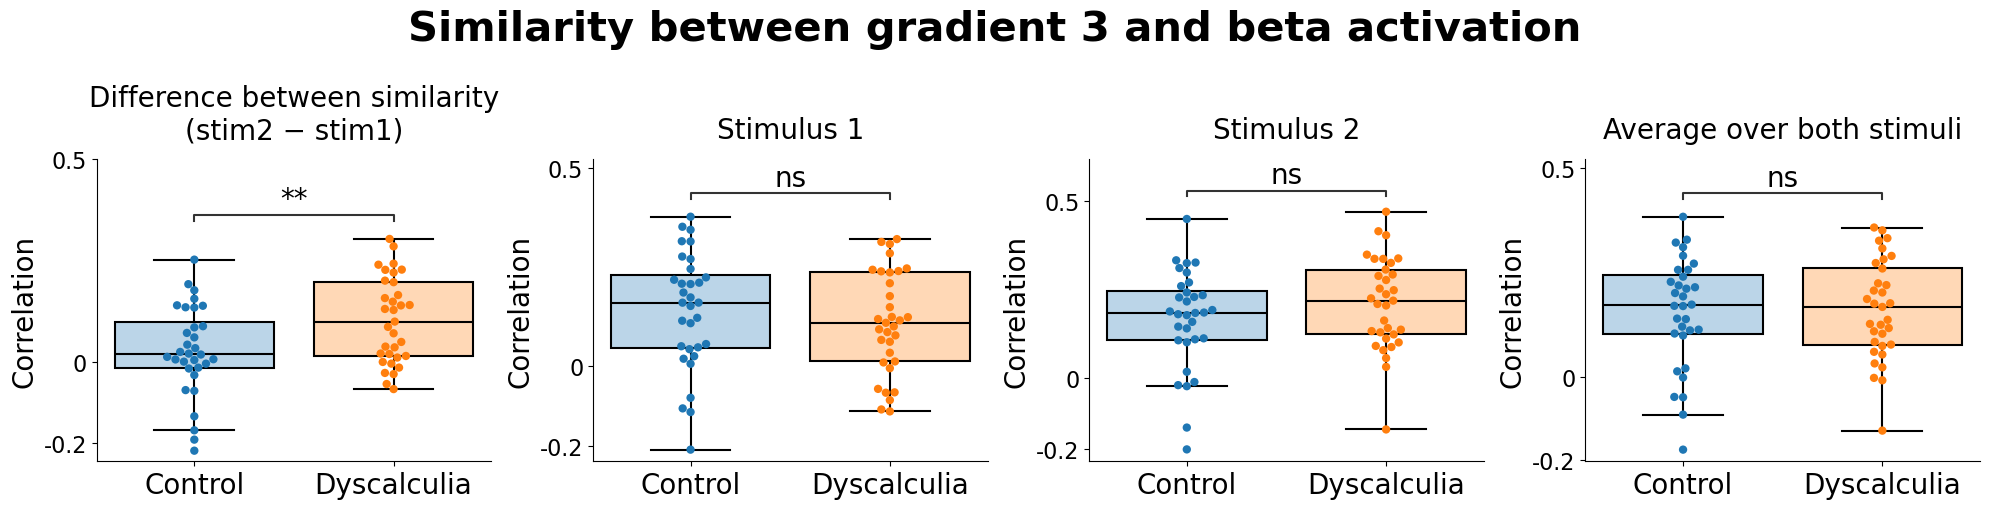

In [ ]:
from scipy.stats import ttest_rel, shapiro, wilcoxon
import matplotlib.colors as mcolors
from statannotations.Annotator import Annotator
import seaborn as sns

size_title = 30
size_other = 20
size_axis  = 16

color_stim1  = '#053061'
color_stim2  = '#b2182b'
color_g0     = '#1f77b4'
color_g1     = '#ff7f0e'
colors_stim  = [color_stim1, color_stim2]
colors_group = [color_g0, color_g1]
stim_order   = ['Stimulus 1', 'Stimulus 2']
group_order  = ['Control', 'Dyscalculia']

# ---- add group labels ----
df_corrs['group_label'] = df_corrs['sub'].apply(
    lambda s: 'Control' if s in sublist_group0 else ('Dyscalculia' if s in sublist_group1 else None)
)
df_corrs_valid = df_corrs.dropna(subset=['group_label'])

# ---- reshape to long ----
valid = df_corrs['corr_1'].notna() & df_corrs['corr_2'].notna()
df_plot = pd.melt(
    df_corrs[valid].reset_index(drop=True),
    id_vars=['sub', 'group_label'],
    value_vars=['corr_1', 'corr_2'],
    var_name='stimulus',
    value_name='correlation'
)
df_plot['stimulus'] = df_plot['stimulus'].map({'corr_1': 'Stimulus 1', 'corr_2': 'Stimulus 2'})
df_plot = df_plot.dropna(subset=['group_label'])

# ---- build diff df ----
diffs = {'sub': [], 'group': [], 'diff': []}
for sub in sublist_group0:
    diff = df_corrs[df_corrs['sub'] == sub]['corr_2'].item() - df_corrs[df_corrs['sub'] == sub]['corr_1'].item()
    diffs['sub'].append(sub); diffs['diff'].append(diff); diffs['group'].append('Control')
for sub in sublist_group1:
    diff = df_corrs[df_corrs['sub'] == sub]['corr_2'].item() - df_corrs[df_corrs['sub'] == sub]['corr_1'].item()
    diffs['sub'].append(sub); diffs['diff'].append(diff); diffs['group'].append('Dyscalculia')
df_diffs_group = pd.DataFrame(diffs)

# ---- build overall df ----
df_corrs_valid['corr_mean'] = (df_corrs_valid['corr_1'] + df_corrs_valid['corr_2']) / 2
df_overall = df_corrs_valid[['sub', 'group_label', 'corr_mean']].copy()

# ---- normality checks ----
diff_vals = df_corrs['corr_1'] - df_corrs['corr_2']
_, p_sw = shapiro(diff_vals.dropna())
stat_test_paired = 't-test_paired' if p_sw > 0.05 else 'Wilcoxon'
print(f"Shapiro-Wilk on difference: p={p_sw:.3f} → using {stat_test_paired}")

normality_passed_diff = all(shapiro(df_diffs_group.loc[df_diffs_group['group'] == g, 'diff'])[1] > 0.05 for g in group_order)
stat_test_diff = 't-test_ind' if normality_passed_diff else 'Mann-Whitney'
print(f"Using for diff plot: {stat_test_diff}")

normality_passed_overall = all(shapiro(df_overall.loc[df_overall['group_label'] == g, 'corr_mean'])[1] > 0.05 for g in group_order)
stat_test_overall = 't-test_ind' if normality_passed_overall else 'Mann-Whitney'
print(f"Using for overall plot: {stat_test_overall}")

normality_s1 = all(shapiro(df_plot[(df_plot['stimulus'] == 'Stimulus 1') & (df_plot['group_label'] == g)]['correlation'].dropna())[1] > 0.05 for g in group_order)
stat_test_s1 = 't-test_ind' if normality_s1 else 'Mann-Whitney'

normality_s2 = all(shapiro(df_plot[(df_plot['stimulus'] == 'Stimulus 2') & (df_plot['group_label'] == g)]['correlation'].dropna())[1] > 0.05 for g in group_order)
stat_test_s2 = 't-test_ind' if normality_s2 else 'Mann-Whitney'

# ---- helper: boxplot + swarm + annotator ----
def plot_box(ax, data, x, y, order, colors, stat_test, title, ylabel, pairs, lines_col=None):
    sns.boxplot(data=data, x=x, y=y, order=order,
                hue=x, hue_order=order, legend=False,
                palette=colors, showfliers=False,
                linecolor='black', linewidth=1.5, ax=ax)
    for i, patch in enumerate(ax.patches):
        r, g, b, _ = mcolors.to_rgba(colors[i])
        patch.set_facecolor((r, g, b, 0.3))
        patch.set_edgecolor('black')
    if lines_col is not None:
        for sub in data[lines_col].unique():
            subj = data[data[lines_col] == sub].set_index(x).reindex(order)
            ax.plot([0, 1], subj[y].values, color='grey', alpha=0.4, linewidth=1, zorder=0)
    sns.swarmplot(data=data, x=x, y=y, order=order,
                  hue=x, hue_order=order, legend=False,
                  palette=colors, alpha=1, size=6, ax=ax)
    ax.set_yticks([-0.2, 0, 0.5])
    ax.set_yticklabels([-0.2, 0, 0.5], fontsize=size_axis)
    ax.set_title(title, fontsize=size_other, pad=15)
    ax.set_xlabel('')
    ax.set_ylabel(ylabel, fontsize=size_other)
    ax.tick_params(axis='x', labelsize=size_other)
    ax.tick_params(axis='y', labelsize=size_axis)
    ax.grid(False)
    sns.despine(ax=ax)
    annotator = Annotator(ax, pairs, data=data, x=x, y=y, order=order)
    annotator.configure(test=stat_test, text_format='star', loc='inside', fontsize=size_other)
    annotator.apply_test()
    annotator.annotate()

# ---- 1x5 grid ----
fig, axes = plt.subplots(1, 5, figsize=(24, 5))

pairs_stim  = [('Stimulus 1', 'Stimulus 2')]
pairs_group = [('Control', 'Dyscalculia')]

# overall stim comparison (with connecting lines)
plot_box(axes[0], df_plot, 'stimulus', 'correlation', stim_order, colors_stim,
         stat_test_paired, f'Gradient {grad_nr} similarity', 'Correlation',
         pairs_stim, lines_col='sub')

# diff group comparison
df_diffs_group_ytick = df_diffs_group.copy()
plot_box(axes[1], df_diffs_group, 'group', 'diff', group_order, colors_group,
         stat_test_diff, 'Difference between similarity\n(stim2 − stim1)', 'Correlation', pairs_group)

# stim 1 group comparison
df_s1 = df_plot[df_plot['stimulus'] == 'Stimulus 1']
plot_box(axes[2], df_s1, 'group_label', 'correlation', group_order, colors_group,
         stat_test_s1, 'Stimulus 1', 'Correlation', pairs_group)

# stim 2 group comparison
df_s2 = df_plot[df_plot['stimulus'] == 'Stimulus 2']
plot_box(axes[3], df_s2, 'group_label', 'correlation', group_order, colors_group,
         stat_test_s2, 'Stimulus 2', 'Correlation', pairs_group)

# overall mean group comparison
plot_box(axes[4], df_overall, 'group_label', 'corr_mean', group_order, colors_group,
         stat_test_overall, 'Average over both stimuli', 'Correlation', pairs_group)

fig.suptitle(
    f'Similarity between gradient {grad_nr} and beta activation',
    fontsize=size_title, weight='bold', y=1.01
)

plt.tight_layout()
plt.show()

In [35]:
print(df_long_corrs['correlation'].min(), df_long_corrs['correlation'].max())

-0.21040113736099497 0.46999188195077535


In [18]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_rel, wilcoxon, shapiro
from statsmodels.stats.multitest import multipletests

n_bins = 20
results = []

grad_nr = 3
aligned = 'av.timeseries-aligned' # sub-aligned
flipped = '_flipped' #

out_dir = '/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk/derivatives/activation_maps_bins.glmav' # '/home/ubuntu/data/activation_maps_bins.glmav'

df_stim1_nan = pd.read_csv(op.join(out_dir, f"df_stim1_grad{grad_nr}_nan_uneven_new_{aligned}{flipped}.csv"))
df_stim2_nan = pd.read_csv(op.join(out_dir, f"df_stim2_grad{grad_nr}_nan_uneven_new_{aligned}{flipped}.csv"))

for b in range(n_bins):
    col = f"bin_{b}"
    stim1_vals = df_stim1_nan[col].values
    stim2_vals = df_stim2_nan[col].values
    
    # Remove NaNs
    mask = ~np.isnan(stim1_vals) & ~np.isnan(stim2_vals)
    stim1_clean = stim1_vals[mask]
    stim2_clean = stim2_vals[mask]
    
    diff = stim1_clean - stim2_clean
    n_diff = len(diff)
    
    # Test normality of differences
    if n_diff < 3:  # Shapiro requires at least 3 points
        normal = False
    else:
        stat, p_shapiro = shapiro(diff)
        normal = p_shapiro > 0.05  # p>0.05 => fail to reject normality
    
    if normal:
        test_name = "paired t-test"
        t_stat, p_val = ttest_rel(stim1_clean, stim2_clean)
        df = n_diff - 1
    else:
        test_name = "paired t-test"
        t_stat, p_val = ttest_rel(stim1_clean, stim2_clean)
        df = n_diff - 1

        # test_name = "wilcoxon signed-rank"
        # # Wilcoxon requires at least one non-zero difference
        # non_zero_diff = diff[diff != 0]
        # if len(non_zero_diff) == 0:
        #     t_stat, p_val = np.nan, 1.0
        #     df = 0
        # else:
        #     try:
        #         t_stat, p_val = wilcoxon(non_zero_diff)
        #     except ValueError:
        #         t_stat, p_val = np.nan, 1.0
        #     df = len(non_zero_diff)
    
    results.append({
        "bin": b,
        "degrees_of_freedom": df,
        "mean_stim1": np.mean(stim1_clean),
        "mean_stim2": np.mean(stim2_clean),
        "mean_difference (stim1 - stim2)": np.mean(diff),
        "test_used": test_name,
        "statistic": t_stat,
        "p_value": p_val
    })

results_df = pd.DataFrame(results)

# FDR correction across bins
reject, pvals_fdr, _, _ = multipletests(
    results_df["p_value"].values,
    method="fdr_bh"
)
results_df["p_fdr"] = pvals_fdr
results_df["significant_fdr"] = reject

print(results_df)

    bin  degrees_of_freedom  mean_stim1  mean_stim2  \
0     0                  64   -0.012837   -0.017156   
1     1                  64   -0.005988   -0.002608   
2     2                  64    0.005136    0.010428   
3     3                  64    0.019718    0.021376   
4     4                  64    0.033110    0.031875   
5     5                  64    0.038882    0.038361   
6     6                  64    0.041868    0.042311   
7     7                  64    0.043866    0.043035   
8     8                  64    0.045103    0.044579   
9     9                  64    0.046456    0.046373   
10   10                  64    0.049728    0.051165   
11   11                  64    0.049684    0.053753   
12   12                  64    0.052110    0.059506   
13   13                  64    0.052394    0.064953   
14   14                  64    0.051934    0.071168   
15   15                  64    0.050053    0.077545   
16   16                  64    0.050872    0.086357   
17   17   

[fetch_atlas_surf_destrieux] Dataset found in /home/ubuntu/nilearn_data/destrieux_surface


/home/ubuntu/git/percep_mem_decision/dnumrisk_data/my_utils.py:171: UserWarning: 
The following regions are present in the atlas look-up table,
but missing from the atlas image:

 index    name
     0 Unknown

  atlas = datasets.fetch_atlas_surf_destrieux()
/home/ubuntu/git/percep_mem_decision/dnumrisk_data/my_utils.py:171: UserWarning: 
The following regions are present in the atlas look-up table,
but missing from the atlas image:

 index    name
     0 Unknown

  atlas = datasets.fetch_atlas_surf_destrieux()
/tmp/ipykernel_233739/4215450093.py:53: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  nplt.plot_surf_roi(fsaverage.infl_left, bin_L, hemi='left', view='lateral',
/tmp/ipykernel_233739/4215450093.py:56: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  nplt.plot_surf_roi(fsaverage.infl_right, bin_R, hemi='right', view='lateral',
/tmp

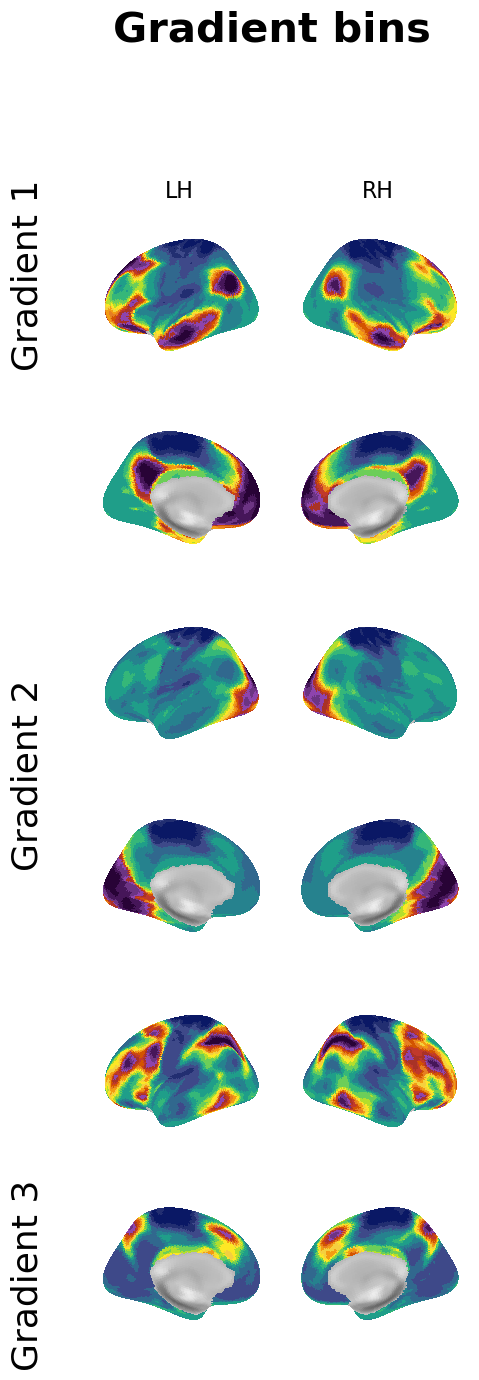

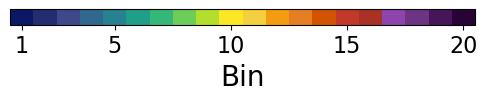

In [22]:
import os.path as op
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import nilearn.plotting as nplt
from nilearn.datasets import fetch_surf_fsaverage
from my_utils import get_basic_mask

# ---- setup ----
mask, labeling_noParcel = get_basic_mask()
fsaverage = fetch_surf_fsaverage()

bids_folder = '/mnt_AdaBD_largefiles/Data/DNumrisk_Data/connectivity_references'
n_bins = 20
grad_nrs = [1, 2, 3]

# ---- colors ----
colors = [
    "#0A1865", "#222E71", "#3E4989", "#31688E", "#26828E",
    "#1F9E89", "#35B779", "#6CCE59", "#B4DE2C", "#FDE725",
    "#F4D03F", "#F39C12", "#E67E22", "#D35400", "#C0392B",
    "#A93226", "#8E44AD", "#6C3483", "#461659", "#280336"
]
cmap = mcolors.ListedColormap(colors)
cmap.set_bad(color='lightgray')

# ---- load gradient file once ----
#grad_all = np.load('/mnt_AdaBD_largefiles/Data/DNumrisk_Data/connectivity_references/dataset-dnumrisk_sub-All_gradients_kernel-normalized_angle_ztransf-True_avMethod-tanH.npy')
grad_all = np.load('/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-numrisk/derivatives/gradients/sub-All/sub-All_ses-1_g-aligned_space-fsaverag5_n10_kernel-normalized_angle.npy')

#grad_all = np.load(op.join(bids_folder, 'dataset-dnumrisk_sub-All_gradients_kernel-normalized_angle_ztransf-True_avMethod-tanH.npy'))

# ---- figure: 6 rows (2 per gradient), 2 columns ----
fig, axes = plt.subplots(6, 2, figsize=(5, 15), subplot_kw=dict(projection='3d'))

for g_idx, grad_nr in enumerate(grad_nrs):
    row_lat = g_idx * 2
    row_med = g_idx * 2 + 1

    # ---- bin assignment ----
    grad_vec_full = grad_all[grad_nr - 1]
    grad_vec = grad_vec_full[mask]
    bin_edges = np.linspace(np.nanmin(grad_vec), np.nanmax(grad_vec), n_bins + 1)
    bin_ass = np.clip(np.digitize(grad_vec, bin_edges, right=True) - 1, 0, n_bins - 1).astype(float)
    bin_vec_full = np.full(len(grad_vec_full), np.nan)
    bin_vec_full[mask] = bin_ass

    n_vertices_L = bin_vec_full.shape[0] // 2
    bin_L = bin_vec_full[:n_vertices_L]
    bin_R = bin_vec_full[n_vertices_L:]

    # lateral
    nplt.plot_surf_roi(fsaverage.infl_left, bin_L, hemi='left', view='lateral',
                       bg_map=fsaverage.sulc_left, cmap=cmap, vmin=0, vmax=n_bins - 1,
                       colorbar=False, axes=axes[row_lat, 0])
    nplt.plot_surf_roi(fsaverage.infl_right, bin_R, hemi='right', view='lateral',
                       bg_map=fsaverage.sulc_right, cmap=cmap, vmin=0, vmax=n_bins - 1,
                       colorbar=False, axes=axes[row_lat, 1])

    # medial
    nplt.plot_surf_roi(fsaverage.infl_left, bin_L, hemi='left', view='medial',
                       bg_map=fsaverage.sulc_left, cmap=cmap, vmin=0, vmax=n_bins - 1,
                       colorbar=False, axes=axes[row_med, 0])
    nplt.plot_surf_roi(fsaverage.infl_right, bin_R, hemi='right', view='medial',
                       bg_map=fsaverage.sulc_right, cmap=cmap, vmin=0, vmax=n_bins - 1,
                       colorbar=False, axes=axes[row_med, 1])

    # column titles on first gradient only
    if g_idx == 0:
        axes[0, 0].set_title("LH", fontsize=16, pad=5)
        axes[0, 1].set_title("RH", fontsize=16, pad=5)

    # gradient label
    fig.text(0.01, 1 - (g_idx + 0.5) / len(grad_nrs), f"Gradient {grad_nr}",
             rotation=90, va='center', ha='center', fontsize=26)

plt.subplots_adjust(hspace=0.05, wspace=0.05)
fig.suptitle("Gradient bins", fontsize=30, y=1.01, weight='bold')

# ---- shared colorbar ----
fig2, ax2 = plt.subplots(figsize=(6, 0.2))
norm = mcolors.Normalize(vmin=0, vmax=n_bins)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, cax=ax2, orientation='horizontal')
cbar.set_ticks([0.5, 4.5, 9.5, 14.5, 19.5])
cbar.set_ticklabels([1, 5, 10, 15, 20])
cbar.ax.tick_params(labelsize=16)
cbar.set_label("Bin", fontsize=20)

plt.show()

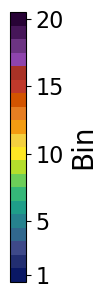

In [30]:
# ---- shared colorbar ----
fig2, ax2 = plt.subplots(figsize=(0.2, 3.5))
norm = mcolors.Normalize(vmin=0, vmax=n_bins)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, cax=ax2, orientation='vertical')
cbar.set_ticks([0.5, 4.5, 9.5, 14.5, 19.5])
cbar.set_ticklabels([1, 5, 10, 15, 20])
cbar.ax.tick_params(labelsize=16)
cbar.set_label("Bin", fontsize=20)

plt.show()

In [31]:
# calculating bin overlap with cole-ant atlas
from my_utils import compute_bin_network_overlap
from my_utils import get_glasser_parcels, get_glasser_CAatlas_mapping

grad_nr = 1
n_bins = 20

# first load atlas vector & mask it --> my_utils
mask, labeling_noParcel = get_basic_mask()
mask_glasser, labeling_glasser = get_glasser_parcels(space='fsaverage5')
glasser_CAatlas_mapping, CAatlas_names = get_glasser_CAatlas_mapping()

from brainspace.utils.parcellation import map_to_labels
caNets_fsav5_mapping = map_to_labels(
    glasser_CAatlas_mapping['ca_network'].values,
    labeling_glasser,
    mask=mask_glasser
)

# append row to network names for label 0
CAatlas_names_new = CAatlas_names.copy()
CAatlas_names_new.loc[0] = 'Unassigned'
CAatlas_names_new = CAatlas_names_new.sort_index()

network_map = caNets_fsav5_mapping[mask]

# from above take bin vector

overlap_norm = {}
networks_dict = {}

#grad_all = np.load('/mnt_AdaBD_largefiles/Data/DNumrisk_Data/connectivity_references/dataset-dnumrisk_sub-All_gradients_kernel-normalized_angle_ztransf-True_avMethod-tanH.npy')
grad_all = np.load('/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-numrisk/derivatives/gradients/sub-All/sub-All_ses-1_g-aligned_space-fsaverag5_n10_kernel-normalized_angle.npy')


for stim in ['1', '2']:

    grad_vec_full = grad_all[grad_nr - 1]
    grad_vec = grad_vec_full[mask]
    bin_edges = np.linspace(np.nanmin(grad_vec), np.nanmax(grad_vec), n_bins + 1)
    bin_ass = np.clip(np.digitize(grad_vec, bin_edges, right=True) - 1, 0, n_bins - 1).astype(float)
    bin_vec = bin_ass
    
    overlap, networks = compute_bin_network_overlap(
        bin_vec,
        network_map,
        n_bins=20
    )

    overlap_norm[stim] = overlap / overlap.sum(axis=1, keepdims=True)

df_stim1 = pd.DataFrame(
    overlap_norm['1'], 
    columns=[CAatlas_names_new.loc[int(n), 'Network Name'] for n in networks]) # columns=[f'{n}' for n in CAatlas_names_new['Network Name']]

df_stim2 = pd.DataFrame(
    overlap_norm['2'], 
    columns=[CAatlas_names_new.loc[int(n), 'Network Name'] for n in networks]) # columns=[f'{n}' for n in CAatlas_names_new['Network Name']]
#df['bin'] = np.arange(n_bins)

[fetch_atlas_surf_destrieux] Dataset found in /home/ubuntu/nilearn_data/destrieux_surface


/home/ubuntu/git/percep_mem_decision/dnumrisk_data/my_utils.py:171: UserWarning: 
The following regions are present in the atlas look-up table,
but missing from the atlas image:

 index    name
     0 Unknown

  atlas = datasets.fetch_atlas_surf_destrieux()
/home/ubuntu/git/percep_mem_decision/dnumrisk_data/my_utils.py:171: UserWarning: 
The following regions are present in the atlas look-up table,
but missing from the atlas image:

 index    name
     0 Unknown

  atlas = datasets.fetch_atlas_surf_destrieux()


In [1]:
# combine bins and recalculate overlap

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

stims = ['1', '2']

for stim in stims:
    # ---- Function to plot a heatmap ----
    def plot_bin_network_heatmap(overlap_matrix, network_names, title="Bin x Network Overlap"):
        plt.figure(figsize=(12, 6))
        sns.heatmap(
            overlap_matrix,
            annot=True,
            fmt=".1f",
            cmap="Reds",
            xticklabels=network_names,
            yticklabels=np.arange(overlap_matrix.shape[0]),
            cbar_kws={'label': 'Normalized overlap'}
        )
        plt.xlabel("CA Network")
        plt.ylabel("Bins / ROIs")
        plt.title(title)
        plt.tight_layout()
        plt.show()

    # ---- Plot original heatmap ----
    plot_bin_network_heatmap(overlap_norm[stim], CAatlas_names_new['Network Name'], title=f"Original Bin-Network Overlap Stimulus {stim}, grad {grad_nr}")

    # ---- Combine bins into custom ROIs ----
    # Example: combine bins 0,1,2 into one ROI; bins 3,4,5 into another, etc.
    roi_definitions = [
        [0,1,2,3,4],
        [15,16,17, 18, 19]
    ]

    combined_rois = []
    for roi_bins in roi_definitions:
        roi_counts = overlap_norm[stim][roi_bins, :].sum(axis=0)          # sum raw counts across selected bins
        roi_norm = roi_counts / roi_counts.sum()                   # normalize
        combined_rois.append(roi_norm)

    combined_rois = np.stack(combined_rois, axis=0)               # shape: (n_ROIs, n_networks)

    # ---- Plot heatmap of combined ROIs ----
    plot_bin_network_heatmap(combined_rois, CAatlas_names_new['Network Name'], title=f"Combined ROI-Network Overlap Stimulus {stim}, grad {grad_nr}")

NameError: name 'overlap_norm' is not defined

In [14]:
subList

['01',
 '02',
 '04',
 '05',
 '06',
 '07',
 '08',
 '09',
 '10',
 '11',
 '12',
 '13',
 '14',
 '15',
 '16',
 '17',
 '18',
 '19',
 '20',
 '21',
 '22',
 '23',
 '24',
 '25',
 '26',
 '27',
 '28',
 '29',
 '30',
 '31',
 '32',
 '33',
 '34',
 '35',
 '36',
 '37',
 '38',
 '39',
 '40',
 '41',
 '42',
 '43',
 '44',
 '45',
 '46',
 '47',
 '48',
 '49',
 '50',
 '51',
 '52',
 '53',
 '54',
 '55',
 '56',
 '57',
 '58',
 '59',
 '60',
 '61',
 '62',
 '63',
 '64',
 '65',
 '66']

[fetch_atlas_surf_destrieux] Dataset found in /home/ubuntu/nilearn_data/destrieux_surface


/home/ubuntu/git/percep_mem_decision/dnumrisk_data/my_utils.py:171: UserWarning: 
The following regions are present in the atlas look-up table,
but missing from the atlas image:

 index    name
     0 Unknown

  atlas = datasets.fetch_atlas_surf_destrieux()
/home/ubuntu/git/percep_mem_decision/dnumrisk_data/my_utils.py:171: UserWarning: 
The following regions are present in the atlas look-up table,
but missing from the atlas image:

 index    name
     0 Unknown

  atlas = datasets.fetch_atlas_surf_destrieux()


n subjects included: 65


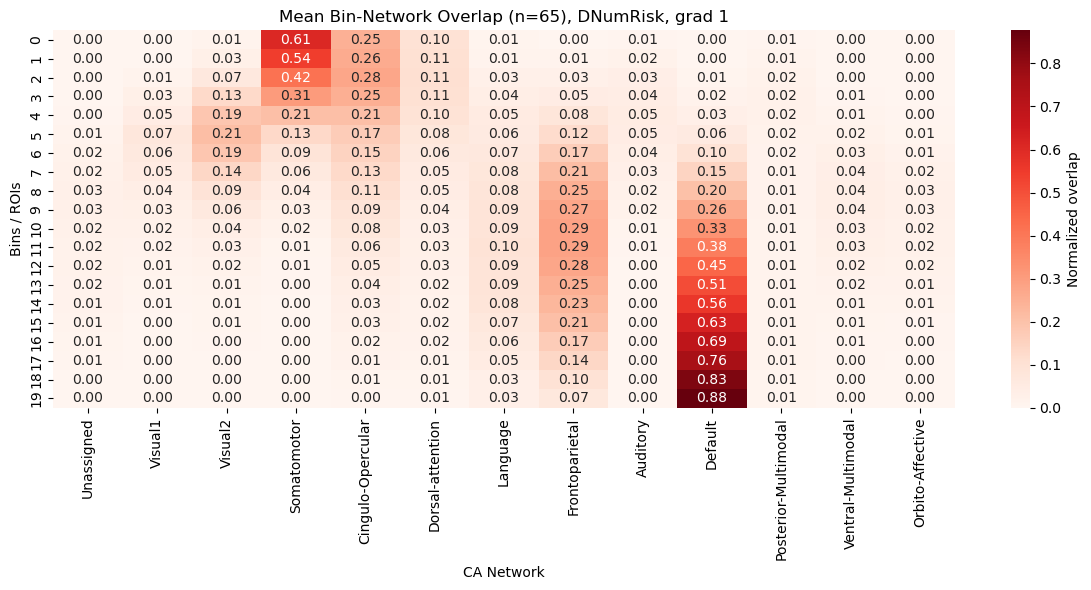

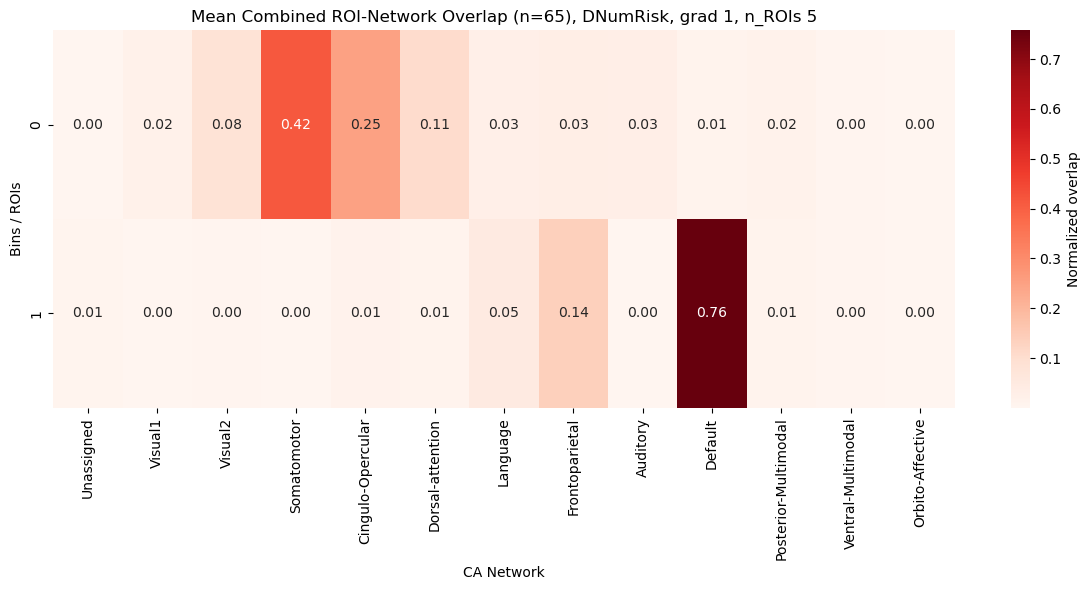

In [ ]:
# bin-network overlap with cole-ant atlas (per subject, mean across subjects)
# DNumRisk dataset
import os
import os.path as op
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from brainspace.utils.parcellation import map_to_labels
from my_utils import (
    compute_bin_network_overlap,
    get_glasser_parcels,
    get_glasser_CAatlas_mapping,
    get_basic_mask,
)


# ---- Settings ----
grad_dir = '/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk/derivatives/gradients.tryParams.36P'
bids_folder = '/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk/'

grad_nr = 1     # or 2, 3
n_bins = 20



# ---- Load atlas & build network map ----
mask, labeling_noParcel = get_basic_mask()
mask_glasser, labeling_glasser = get_glasser_parcels(space='fsaverage5')
glasser_CAatlas_mapping, CAatlas_names = get_glasser_CAatlas_mapping()

caNets_fsav5_mapping = map_to_labels(
    glasser_CAatlas_mapping['ca_network'].values,
    labeling_glasser,
    mask=mask_glasser,
)

CAatlas_names_new = CAatlas_names.copy()
CAatlas_names_new.loc[0] = 'Unassigned'
CAatlas_names_new = CAatlas_names_new.sort_index()

network_map = caNets_fsav5_mapping[mask]


# ---- Per-subject overlap ----
overlap_norm_subj = []
networks_ref = None

for sub in subList:
    folder = Path(grad_dir) / f'sub-{sub}'
    base = f'sub-{sub}_g-aligned-tanH_kernel-normalized_angle_z-transf-True'

    # try _ccfilter first, fall back to no suffix
    sub_path = None
    for suffix in ['_ccfilter', '']:
        candidate = folder / f'{base}{suffix}.npy'
        if candidate.exists():
            sub_path = candidate
            break

    if sub_path is None:
        if folder.exists():
            print(f'No file found for sub-{sub}. Files present: {list(folder.glob("*.npy"))}')
        else:
            print(f'No folder for sub-{sub}')
        continue

    try:
        binning_grad_all = np.load(sub_path)
        binning_grad = binning_grad_all[grad_nr - 1][mask]

        bin_min = np.nanmin(binning_grad)
        bin_max = np.nanmax(binning_grad)
        bin_edges = np.linspace(bin_min, bin_max, n_bins + 1)

        bin_indices = np.digitize(binning_grad, bin_edges, right=True) - 1
        bin_indices = np.clip(bin_indices, 0, n_bins - 1)

        overlap, networks = compute_bin_network_overlap(
            bin_indices,
            network_map,
            n_bins=n_bins,
        )

        if networks_ref is None:
            networks_ref = networks

        row_sums = overlap.sum(axis=1, keepdims=True)
        overlap_n = np.divide(
            overlap, row_sums,
            where=row_sums != 0,
            out=np.full_like(overlap, np.nan, dtype=float),
        )

        overlap_norm_subj.append(overlap_n)

    except Exception as e:
        print(f'Error for sub-{sub}: {e}')
        continue

overlap_norm_subj = np.stack(overlap_norm_subj, axis=0)   # (n_subjects, n_bins, n_networks)
overlap_mean = np.nanmean(overlap_norm_subj, axis=0)      # (n_bins, n_networks)

print(f'n subjects included: {overlap_norm_subj.shape[0]}')


# ---- DataFrame of mean overlap ----
df_mean = pd.DataFrame(
    overlap_mean,
    columns=[CAatlas_names_new.loc[int(n), 'Network Name'] for n in networks_ref],
)


# ---- Plotting function ----
def plot_bin_network_heatmap(overlap_matrix, network_names, title="Bin x Network Overlap"):
    plt.figure(figsize=(12, 6))
    sns.heatmap(
        overlap_matrix,
        annot=True,
        fmt=".2f",
        cmap="Reds",
        xticklabels=network_names,
        yticklabels=np.arange(overlap_matrix.shape[0]),
        cbar_kws={'label': 'Normalized overlap'},
    )
    plt.xlabel("CA Network")
    plt.ylabel("Bins / ROIs")
    plt.title(title)
    plt.tight_layout()
    plt.show()


# ---- Plot mean bin-network overlap ----
plot_bin_network_heatmap(
    overlap_mean,
    CAatlas_names_new['Network Name'],
    title=f"Mean Bin-Network Overlap (n={overlap_norm_subj.shape[0]}), DNumRisk, grad {grad_nr}",
)


# ---- Combine bins into custom ROIs (per subject, then mean) ----
roi_definitions = [
    [0, 1, 2, 3, 4],
    [15, 16, 17, 18, 19]
]

combined_subj = []
for sub_overlap in overlap_norm_subj:
    rois = []
    for roi_bins in roi_definitions:
        roi_counts = sub_overlap[roi_bins, :].sum(axis=0)
        roi_norm = roi_counts / roi_counts.sum()
        rois.append(roi_norm)
    combined_subj.append(np.stack(rois, axis=0))

combined_subj = np.stack(combined_subj, axis=0)         # (n_subjects, n_ROIs, n_networks)
combined_mean = np.nanmean(combined_subj, axis=0)       # (n_ROIs, n_networks)

plot_bin_network_heatmap(
    combined_mean,
    CAatlas_names_new['Network Name'],
    title=(
        f"Mean Combined ROI-Network Overlap (n={combined_subj.shape[0]}), "
        f"DNumRisk, grad {grad_nr}, n_ROIs {len(roi_definitions[0])}"
    ),
)

[fetch_atlas_surf_destrieux] Dataset found in /home/ubuntu/nilearn_data/destrieux_surface


/home/ubuntu/git/percep_mem_decision/dnumrisk_data/my_utils.py:171: UserWarning: 
The following regions are present in the atlas look-up table,
but missing from the atlas image:

 index    name
     0 Unknown

  atlas = datasets.fetch_atlas_surf_destrieux()
/home/ubuntu/git/percep_mem_decision/dnumrisk_data/my_utils.py:171: UserWarning: 
The following regions are present in the atlas look-up table,
but missing from the atlas image:

 index    name
     0 Unknown

  atlas = datasets.fetch_atlas_surf_destrieux()


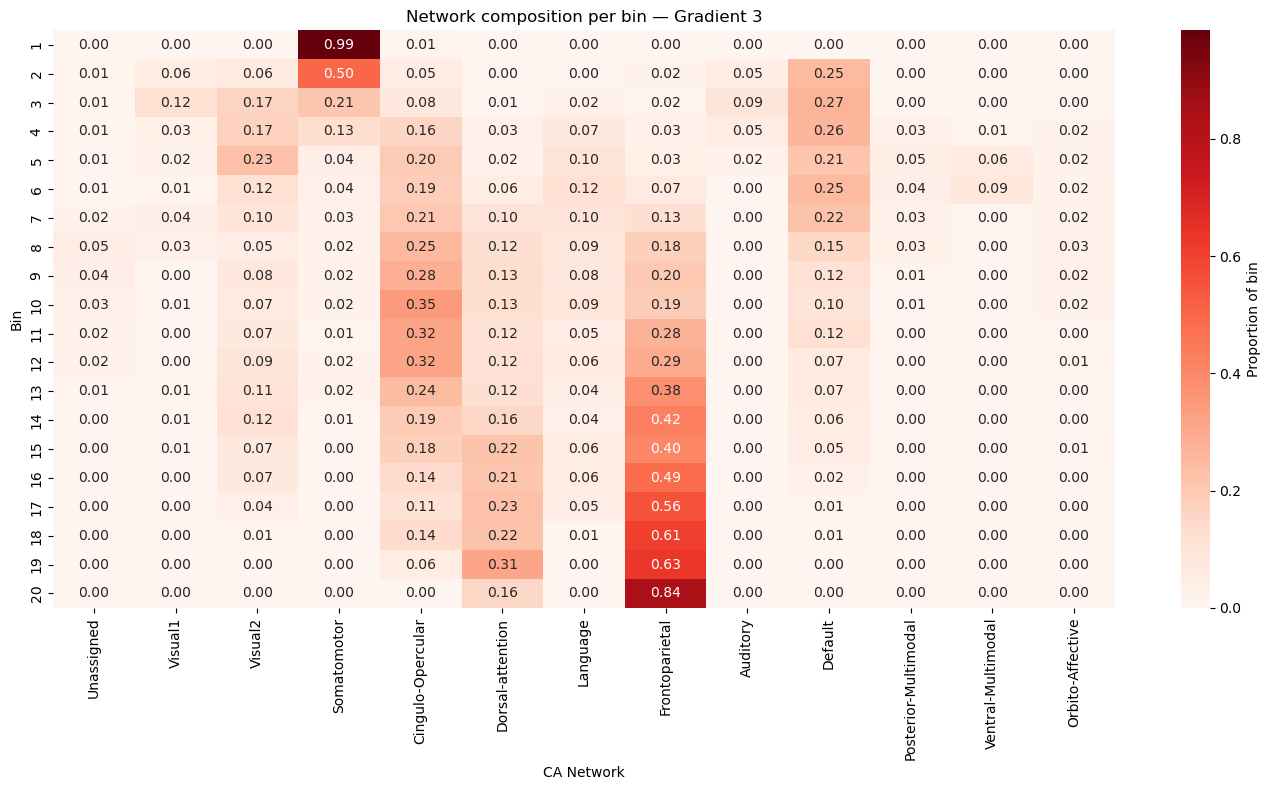

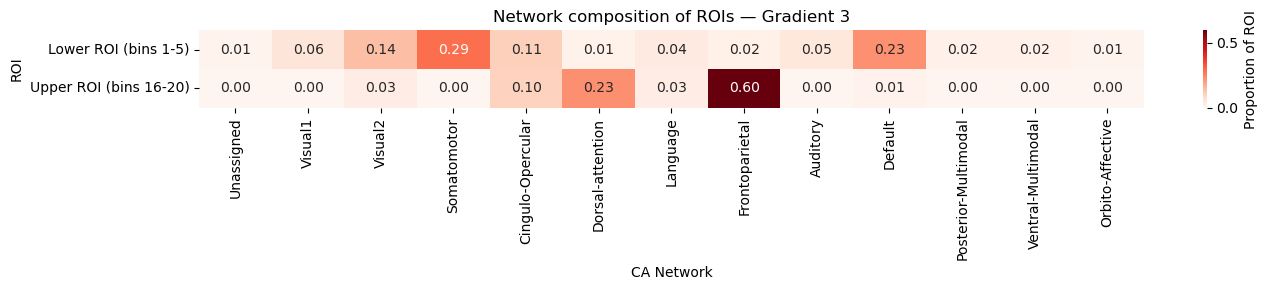

In [ ]:
from my_utils import compute_bin_network_overlap
from my_utils import get_glasser_parcels, get_glasser_CAatlas_mapping
from brainspace.utils.parcellation import map_to_labels
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

grad_nr = 1
n_bins  = 20

# ---- load atlas ----
mask, labeling_noParcel     = get_basic_mask()
mask_glasser, labeling_glasser = get_glasser_parcels(space='fsaverage5')
glasser_CAatlas_mapping, CAatlas_names = get_glasser_CAatlas_mapping()

caNets_fsav5_mapping = map_to_labels(
    glasser_CAatlas_mapping['ca_network'].values,
    labeling_glasser,
    mask=mask_glasser
)

CAatlas_names_new = CAatlas_names.copy()
CAatlas_names_new.loc[0] = 'Unassigned'
CAatlas_names_new = CAatlas_names_new.sort_index()

network_map = caNets_fsav5_mapping[mask]

# ---- load group-average gradient and compute bin assignment ----
grad_all = np.load('/mnt_AdaBD_largefiles/Data/DNumrisk_Data/connectivity_references/dataset-dnumrisk_sub-All_gradients_kernel-normalized_angle_ztransf-True_avMethod-tanH.npy')

grad_vec_full = grad_all[grad_nr - 1]
grad_vec      = grad_vec_full[mask]
bin_edges     = np.linspace(np.nanmin(grad_vec), np.nanmax(grad_vec), n_bins + 1)
bin_ass       = np.clip(np.digitize(grad_vec, bin_edges, right=True) - 1, 0, n_bins - 1).astype(float)

# ---- compute overlap ----
overlap, networks = compute_bin_network_overlap(bin_ass, network_map, n_bins=n_bins)
network_names     = [CAatlas_names_new.loc[int(n), 'Network Name'] for n in networks]

# ---- plot per-bin heatmap ----
overlap_norm_bins = overlap / overlap.sum(axis=1, keepdims=True)

plt.figure(figsize=(14, 8))
sns.heatmap(
    overlap_norm_bins,
    annot=True,
    fmt='.2f',
    cmap='Reds',
    xticklabels=network_names,
    yticklabels=np.arange(1, n_bins + 1),
    cbar_kws={'label': 'Proportion of bin'}
)
plt.xlabel('CA Network')
plt.ylabel('Bin')
plt.title(f'Network composition per bin — Gradient {grad_nr}')
plt.tight_layout()
plt.show()

# ---- compute ROI-level overlap ----
roi_definitions = {
    'Lower ROI (bins 1-5)':   list(range(0,5)),
    'Upper ROI (bins 16-20)': list(range(15, 20)),
}

combined_rois = []
roi_labels    = []
for roi_label, roi_bins in roi_definitions.items():
    roi_counts = overlap[roi_bins, :].sum(axis=0)  # sum raw counts across bins
    roi_norm   = roi_counts / roi_counts.sum()      # normalize so it sums to 1
    combined_rois.append(roi_norm)
    roi_labels.append(roi_label)

combined_rois = np.stack(combined_rois, axis=0)  # shape: (2, n_networks)

# ---- plot ROI heatmap ----
plt.figure(figsize=(14, 3))
sns.heatmap(
    combined_rois,
    annot=True,
    fmt='.2f',
    cmap='Reds',
    xticklabels=network_names,
    yticklabels=roi_labels,
    cbar_kws={'label': 'Proportion of ROI'}
)
plt.xlabel('CA Network')
plt.ylabel('ROI')
plt.title(f'Network composition of ROIs — Gradient {grad_nr}')
plt.tight_layout()
plt.show()